In [1]:
# Cell 1 — imports
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pd_estim_A.eval.eval_bayes as eval_bayes
importlib.reload(eval_bayes)

from pd_estim_A.eval.eval_bayes import (
    build_bayesian_nig_evaluation_dataframe,
    build_bayesian_merton_evaluation_dataframe,
    merge_bayesian_interval_panels,
    run_all_interval_calibrations_three_way,
    run_pairwise_interval_dm,
    plot_interval_panels_by_firm,
    plot_average_interval,
)

In [2]:
# Cell 2 — configuration
model_data_dir = Path("../data/derived")

nig_subdir = "bayesian_nig"
nig_file = "bayes_nig_oos_weekly_condfixA_iter12000_burn2000_thin10_firms21_wins36.csv"

merton_subdir = ""
merton_file = "bayesian_merton_oos_weekly.csv"

rf_path = "../data/raw/ecb_yc_1y_aaa.csv"
cds_file = "CDS_panel.csv"

BENCH = "PD_1y_CDS_par"
NOMINAL_COVERAGE = 0.95
CALIBRATION_SCALE = "logit"       # or "level"
WIDTH_OBJECTIVE = "interval_score"
FIRM_MIN_OBS = 20

FIT_END = "2018-12-31"
VALID_END = "2020-12-31"
TEST_END = "2024-12-31"

MAIN_VARIANTS = ("standard", "shift", "k")
ROBUST_VARIANTS = ("firm_shift",)
ALL_VARIANTS = ("standard", "shift", "k", "firm_shift")

N_FIRMS_PLOT = None
USE_SPECIFIC_FIRMS = None

print("Calibration scale :", CALIBRATION_SCALE)
print("Fit period        : <= ", FIT_END)
print("Validation period : ", pd.Timestamp(FIT_END) + pd.Timedelta(days=1), "to", VALID_END)
print("Forecast test     : ", pd.Timestamp(VALID_END) + pd.Timedelta(days=1), "to", TEST_END)

Calibration scale : logit
Fit period        : <=  2018-12-31
Validation period :  2019-01-01 00:00:00 to 2020-12-31
Forecast test     :  2021-01-01 00:00:00 to 2024-12-31


In [3]:
# Cell 3 — build evaluation-ready panels
eval_nig = build_bayesian_nig_evaluation_dataframe(
    derived_dir=model_data_dir,
    rf_path=rf_path,
    nig_subdir=nig_subdir,
    nig_file=nig_file,
    cds_file=cds_file,
    recovery=0.40,
    cds_unit="auto",
)

eval_merton = build_bayesian_merton_evaluation_dataframe(
    derived_dir=model_data_dir,
    rf_path=rf_path,
    merton_subdir=merton_subdir,
    merton_file=merton_file,
    cds_file=cds_file,
    recovery=0.40,
    cds_unit="auto",
)

DROP_GVKEYS = {
    "241456",
    "101336",
    "17436",
    "201794",
    "220940",
    "100022",
    "221616",
    "61616",
    "101202",
    "17452",
}

for df_name, df in [("eval_merton", eval_merton), ("eval_nig", eval_nig)]:
    if "gvkey" in df.columns:
        df["gvkey"] = df["gvkey"].astype(str)
        df = df.loc[~df["gvkey"].isin(DROP_GVKEYS)].copy()

    if df_name == "eval_merton":
        eval_merton = df
    elif df_name == "eval_nig":
        eval_nig = df

print("NIG rows   :", len(eval_nig), "firms:", eval_nig["gvkey"].nunique())
print("Merton rows:", len(eval_merton), "firms:", eval_merton["gvkey"].nunique())

display(eval_nig.head())
display(eval_merton.head())

NIG rows   : 5170 firms: 11
Merton rows: 5346 firms: 11


,gvkey,date,window_idx,rf_used,B_used,asset_NIG_lo,asset_NIG_med,asset_NIG_hi,asset_NIG_mean,PD_Q_NIG_lo,...,PD_P_NIG_hi,PD_P_NIG_mean,cds,r_f,lambda_CDS_triangle,PD_1y_CDS_triangle,lambda_CDS_par,PD_1y_CDS_par,gvkey_x,gvkey_y
314,100080,2016-01-01,0,-0.003968,5.001600e+10,1.459754e+11,1.459754e+11,1.459754e+11,1.459754e+11,1.859717e-12,...,6.749167e-07,1.813491e-07,16.91,-0.003968,0.002818,0.002814,0.002818,0.002814,100080,100080
315,100080,2016-01-08,0,-0.004354,5.001600e+10,1.361541e+11,1.361541e+11,1.361541e+11,1.361541e+11,3.995316e-11,...,4.085312e-06,9.039964e-07,21.90,-0.004354,0.003650,0.003643,0.003650,0.003643,100080,100080
316,100080,2016-01-15,0,-0.004190,5.001600e+10,1.334170e+11,1.334170e+11,1.334170e+11,1.334170e+11,9.320937e-11,...,6.638535e-06,1.415865e-06,23.91,-0.004190,0.003985,0.003977,0.003985,0.003977,100080,100080
317,100080,2016-01-22,0,-0.004325,5.001600e+10,1.375171e+11,1.375171e+11,1.375171e+11,1.375171e+11,2.608885e-11,...,3.207794e-06,7.230880e-07,25.96,-0.004325,0.004327,0.004317,0.004327,0.004317,100080,100080
318,100080,2016-01-29,0,-0.004508,5.001600e+10,1.357484e+11,1.357484e+11,1.357484e+11,1.357484e+11,4.566894e-11,...,4.390226e-06,9.661474e-07,25.16,-0.004508,0.004193,0.004185,0.004193,0.004185,100080,100080


,gvkey,date,window_idx,rf_used,B_used,asset_Merton_lo,asset_Merton_med,asset_Merton_hi,asset_Merton_mean,PD_Q_Merton_lo,...,PD_P_Merton_hi,PD_P_Merton_mean,cds,r_f,lambda_CDS_triangle,PD_1y_CDS_triangle,lambda_CDS_par,PD_1y_CDS_par,gvkey_x,gvkey_y
486,100080,2016-01-01,0,-0.003968,5.001600e+10,1.459754e+11,1.459754e+11,1.459755e+11,1.459754e+11,6.685202e-09,...,0.000026,0.000007,16.91,-0.003968,0.002818,0.002814,0.002818,0.002814,100080,100080
487,100080,2016-01-08,0,-0.004354,5.001600e+10,1.361541e+11,1.361541e+11,1.361542e+11,1.361541e+11,5.716750e-08,...,0.000087,0.000019,21.90,-0.004354,0.003650,0.003643,0.003650,0.003643,100080,100080
488,100080,2016-01-15,0,-0.004190,5.001600e+10,1.334169e+11,1.334170e+11,1.334170e+11,1.334170e+11,1.032784e-07,...,0.000126,0.000025,23.91,-0.004190,0.003985,0.003977,0.003985,0.003977,100080,100080
489,100080,2016-01-22,0,-0.004325,5.001600e+10,1.375171e+11,1.375171e+11,1.375172e+11,1.375171e+11,4.245302e-08,...,0.000073,0.000016,25.96,-0.004325,0.004327,0.004317,0.004327,0.004317,100080,100080
490,100080,2016-01-29,0,-0.004508,5.001600e+10,1.357483e+11,1.357484e+11,1.357484e+11,1.357484e+11,6.273248e-08,...,0.000092,0.000020,25.16,-0.004508,0.004193,0.004185,0.004193,0.004185,100080,100080


In [4]:
# Cell 4 — common overlap panel
eval_overlap = merge_bayesian_interval_panels(
    eval_merton,
    eval_nig,
)

print("Overlap rows :", len(eval_overlap))
print("Overlap firms:", eval_overlap["gvkey"].nunique())
print("Date range   :", eval_overlap["date"].min(), "->", eval_overlap["date"].max())

cols_show = [
    "gvkey", "date",
    "PD_Q_Merton_lo", "PD_Q_Merton_med", "PD_Q_Merton_hi",
    "PD_Q_NIG_lo", "PD_Q_NIG_med", "PD_Q_NIG_hi",
    BENCH,
]
cols_show = [c for c in cols_show if c in eval_overlap.columns]
display(eval_overlap[cols_show].head())

Overlap rows : 5170
Overlap firms: 11
Date range   : 2016-01-01 00:00:00 -> 2024-12-27 00:00:00


,gvkey,date,PD_Q_Merton_lo,PD_Q_Merton_med,PD_Q_Merton_hi,PD_Q_NIG_lo,PD_Q_NIG_med,PD_Q_NIG_hi,PD_1y_CDS_par
0,100080,2016-01-01,6.685202e-09,2.622143e-07,0.000008,1.859717e-12,7.190531e-10,1.288792e-08,0.002814
1,100080,2016-01-08,5.716750e-08,1.427161e-06,0.000027,3.995316e-11,7.587718e-09,9.643180e-08,0.003643
2,100080,2016-01-15,1.032784e-07,2.276922e-06,0.000039,9.320937e-11,1.453343e-08,1.681384e-07,0.003977
3,100080,2016-01-22,4.245302e-08,1.128267e-06,0.000023,2.608885e-11,5.469082e-09,7.290697e-08,0.004317
4,100080,2016-01-29,6.273248e-08,1.535801e-06,0.000029,4.566894e-11,8.398803e-09,1.052677e-07,0.004185


In [5]:
# Cell 5 — run 3-way evaluation for both models
res_nig = run_all_interval_calibrations_three_way(
    eval_overlap,
    model_label="NIG",
    lo_col="PD_Q_NIG_lo",
    med_col="PD_Q_NIG_med",
    hi_col="PD_Q_NIG_hi",
    fit_end=FIT_END,
    valid_end=VALID_END,
    test_end=TEST_END,
    target_col=BENCH,
    nominal_coverage=NOMINAL_COVERAGE,
    calibration_scale=CALIBRATION_SCALE,
    variants=ALL_VARIANTS,
    selection_variants=MAIN_VARIANTS,
    selection_metric="mean_interval_score",
    width_objective=WIDTH_OBJECTIVE,
    firm_min_obs=FIRM_MIN_OBS,
)

res_merton = run_all_interval_calibrations_three_way(
    eval_overlap,
    model_label="Merton",
    lo_col="PD_Q_Merton_lo",
    med_col="PD_Q_Merton_med",
    hi_col="PD_Q_Merton_hi",
    fit_end=FIT_END,
    valid_end=VALID_END,
    test_end=TEST_END,
    target_col=BENCH,
    nominal_coverage=NOMINAL_COVERAGE,
    calibration_scale=CALIBRATION_SCALE,
    variants=ALL_VARIANTS,
    selection_variants=MAIN_VARIANTS,
    selection_metric="mean_interval_score",
    width_objective=WIDTH_OBJECTIVE,
    firm_min_obs=FIRM_MIN_OBS,
)

print("NIG split info")
display(pd.DataFrame([res_nig["split_info"]]))

print("Merton split info")
display(pd.DataFrame([res_merton["split_info"]]))

NIG split info


,start_date_used,fit_end,valid_end,test_end,fit_n,valid_n,test_n,fit_min_date,fit_max_date,valid_min_date,valid_max_date,test_min_date,test_max_date
0,None,2018-12-31,2020-12-31,2024-12-31,1727,1144,2299,2016-01-01,2018-12-28,2019-01-04,2020-12-25,2021-01-01,2024-12-27


Merton split info


,start_date_used,fit_end,valid_end,test_end,fit_n,valid_n,test_n,fit_min_date,fit_max_date,valid_min_date,valid_max_date,test_min_date,test_max_date
0,None,2018-12-31,2020-12-31,2024-12-31,1727,1144,2299,2016-01-01,2018-12-28,2019-01-04,2020-12-25,2021-01-01,2024-12-27


In [6]:
# Cell 6 — calibrators, selection, summary tables
print("NIG calibrator table")
display(res_nig["calibrator_table"])

print("Merton calibrator table")
display(res_merton["calibrator_table"])

print("NIG main-variant selection on validation")
display(res_nig["selection_table"])

print("Merton main-variant selection on validation")
display(res_merton["selection_table"])

summary_all = pd.concat(
    [res_nig["summary_table"], res_merton["summary_table"]],
    ignore_index=True,
)

display(
    summary_all.sort_values(["sample", "variant", "model"]).reset_index(drop=True)
)

print("Selected main variant — NIG   :", res_nig["selected_variant"])
print("Selected main variant — Merton:", res_merton["selected_variant"])

NIG calibrator table


,model,variant,intercept,slope,scale,eps,n_fit,width_k,width_objective,width_train_n,width_train_empirical_coverage,width_train_mean_width,width_train_mean_interval_score,firm_min_obs,n_firm_specific_calibrators,n_firm_fallbacks
0,NIG,standard,-6.125137,0.01107,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NIG,shift,-6.125137,0.01107,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NIG,k,-6.125137,0.01107,logit,0.000001,1727,20.0,interval_score,1727.0,0.149392,0.000591,0.043373,NaN,NaN,NaN
3,NIG,firm_shift,-6.125137,0.01107,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,20.0,11.0,0.0


Merton calibrator table


,model,variant,intercept,slope,scale,eps,n_fit,width_k,width_objective,width_train_n,width_train_empirical_coverage,width_train_mean_width,width_train_mean_interval_score,firm_min_obs,n_firm_specific_calibrators,n_firm_fallbacks
0,Merton,standard,-6.056957,0.01616,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Merton,shift,-6.056957,0.01616,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Merton,k,-6.056957,0.01616,logit,0.000001,1727,20.0,interval_score,1727.0,0.137232,0.000414,0.044497,NaN,NaN,NaN
3,Merton,firm_shift,-6.056957,0.01616,logit,0.000001,1727,NaN,NaN,NaN,NaN,NaN,NaN,20.0,11.0,0.0


NIG main-variant selection on validation


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med,rank
0,NIG,validation,shift,1144,0.95,0.194056,0.755944,0.002458,0.044431,0.00133,1
1,NIG,validation,k,1144,0.95,0.212413,0.737587,0.001149,0.044697,0.00133,2
2,NIG,validation,standard,1144,0.95,0.018357,0.931643,0.000058,0.052343,0.00133,3


Merton main-variant selection on validation


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med,rank
0,Merton,validation,k,1144,0.95,0.159091,0.790909,0.000573,0.046158,0.001297,1
1,Merton,validation,shift,1144,0.95,0.178322,0.771678,0.003976,0.047139,0.001297,2
2,Merton,validation,standard,1144,0.95,0.010490,0.939510,0.000029,0.051372,0.001297,3


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,fit,firm_shift,1727,0.95,0.106543,0.843457,0.001827,0.027749,0.000686
1,NIG,fit,firm_shift,1727,0.95,0.126809,0.823191,0.005447,0.031094,0.000724
2,Merton,fit,k,1727,0.95,0.137232,0.812768,0.000414,0.044497,0.001250
3,NIG,fit,k,1727,0.95,0.149392,0.800608,0.000591,0.043373,0.001249
4,Merton,fit,raw,1727,0.95,0.028373,0.921627,0.002379,0.104131,0.003298
5,NIG,fit,raw,1727,0.95,0.079907,0.870093,0.009622,1.631380,0.045102
6,Merton,fit,shift,1727,0.95,0.103069,0.846931,0.001836,0.049487,0.001250
7,NIG,fit,shift,1727,0.95,0.130863,0.819137,0.005450,0.050624,0.001249
8,Merton,fit,standard,1727,0.95,0.009265,0.940735,0.000021,0.049571,0.001250
9,NIG,fit,standard,1727,0.95,0.009265,0.940735,0.000030,0.049380,0.001249


Selected main variant — NIG   : shift
Selected main variant — Merton: k


In [7]:
# Cell 7 — build joint validation/test panels for model comparison
def build_joint_panel(left_df: pd.DataFrame, right_df: pd.DataFrame, right_model: str) -> pd.DataFrame:
    prefixes = (f"{right_model}_Q_", f"IS_")
    right_extra = [c for c in right_df.columns if c.startswith(prefixes) and c not in left_df.columns]

    return (
        left_df.merge(
            right_df[["gvkey", "date"] + right_extra],
            on=["gvkey", "date"],
            how="inner",
            validate="one_to_one",
        )
        .sort_values(["gvkey", "date"])
        .reset_index(drop=True)
    )

joint_valid = build_joint_panel(res_merton["validation_df"], res_nig["validation_df"], right_model="NIG")
joint_test = build_joint_panel(res_merton["test_df"], res_nig["test_df"], right_model="NIG")

dm_valid = run_pairwise_interval_dm(
    joint_valid,
    model_a="Merton",
    model_b="NIG",
    variants=("raw", "standard", "shift", "k", "firm_shift"),
    L=None,
    sample_name="validation",
)

dm_test = run_pairwise_interval_dm(
    joint_test,
    model_a="Merton",
    model_b="NIG",
    variants=("raw", "standard", "shift", "k", "firm_shift"),
    L=None,
    sample_name="test",
)

print("DM / HAC — validation")
display(dm_valid)

print("DM / HAC — forecast test")
display(dm_test)

DM / HAC — validation


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,104,-0.391569,0.244614,-1.600764,0.109429,4,IS_raw_Merton,IS_raw_NIG,Merton,NIG,raw,validation
1,104,-0.000971,0.000224,-4.327459,0.000015,4,IS_standard_Merton,IS_standard_NIG,Merton,NIG,standard,validation
2,104,0.002708,0.000626,4.327917,0.000015,4,IS_shift_Merton,IS_shift_NIG,Merton,NIG,shift,validation
3,104,0.001460,0.000600,2.435950,0.014853,4,IS_k_Merton,IS_k_NIG,Merton,NIG,k,validation
4,104,-2.572202,0.236699,-10.866972,0.000000,4,IS_firm_shift_Merton,IS_firm_shift_NIG,Merton,NIG,firm_shift,validation


DM / HAC — forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,0.016949,0.006608,2.564827,1.032273e-02,4,IS_raw_Merton,IS_raw_NIG,Merton,NIG,raw,test
1,209,-0.000145,0.000064,-2.273231,2.301226e-02,4,IS_standard_Merton,IS_standard_NIG,Merton,NIG,standard,test
2,209,0.002198,0.000357,6.151271,7.686451e-10,4,IS_shift_Merton,IS_shift_NIG,Merton,NIG,shift,test
3,209,-0.000337,0.000404,-0.835643,4.033559e-01,4,IS_k_Merton,IS_k_NIG,Merton,NIG,k,test
4,209,-2.105444,0.249970,-8.422771,0.000000e+00,4,IS_firm_shift_Merton,IS_firm_shift_NIG,Merton,NIG,firm_shift,test


In [8]:
# Cell 8 — helper functions for sections below
def cols_for_variant(model_label: str, variant: str):
    if variant == "raw":
        if model_label == "NIG":
            return "PD_Q_NIG_lo", "PD_Q_NIG_med", "PD_Q_NIG_hi"
        if model_label == "Merton":
            return "PD_Q_Merton_lo", "PD_Q_Merton_med", "PD_Q_Merton_hi"
        raise ValueError("Unknown model label")

    return (
        f"{model_label}_Q_{variant}_lo",
        f"{model_label}_Q_{variant}_med",
        f"{model_label}_Q_{variant}_hi",
    )

def show_summary_tables(variant: str):
    print(f"\n===== {variant.upper()} : VALIDATION =====")
    display(
        summary_all[
            (summary_all["sample"] == "validation") &
            (summary_all["variant"] == variant)
        ]
        .sort_values("model")
        .reset_index(drop=True)
    )

    print(f"\n===== {variant.upper()} : FORECAST TEST =====")
    display(
        summary_all[
            (summary_all["sample"] == "test") &
            (summary_all["variant"] == variant)
        ]
        .sort_values("model")
        .reset_index(drop=True)
    )

    dm_src = dm_test if variant in dm_test["variant"].values else pd.DataFrame()
    if not dm_src.empty:
        print("\nDM / HAC on forecast test")
        display(dm_src.loc[dm_src["variant"] == variant].reset_index(drop=True))


===== RAW : VALIDATION =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,validation,raw,1144,0.95,0.070804,0.879196,0.006088,0.199240,0.007233
1,NIG,validation,raw,1144,0.95,0.159091,0.790909,0.003001,0.590809,0.015704



===== RAW : FORECAST TEST =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,test,raw,2299,0.95,0.090039,0.859961,0.001278,0.097545,0.002807
1,NIG,test,raw,2299,0.95,0.125272,0.824728,0.001775,0.080596,0.002397



DM / HAC on forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,0.016949,0.006608,2.564827,0.010323,4,IS_raw_Merton,IS_raw_NIG,Merton,NIG,raw,test


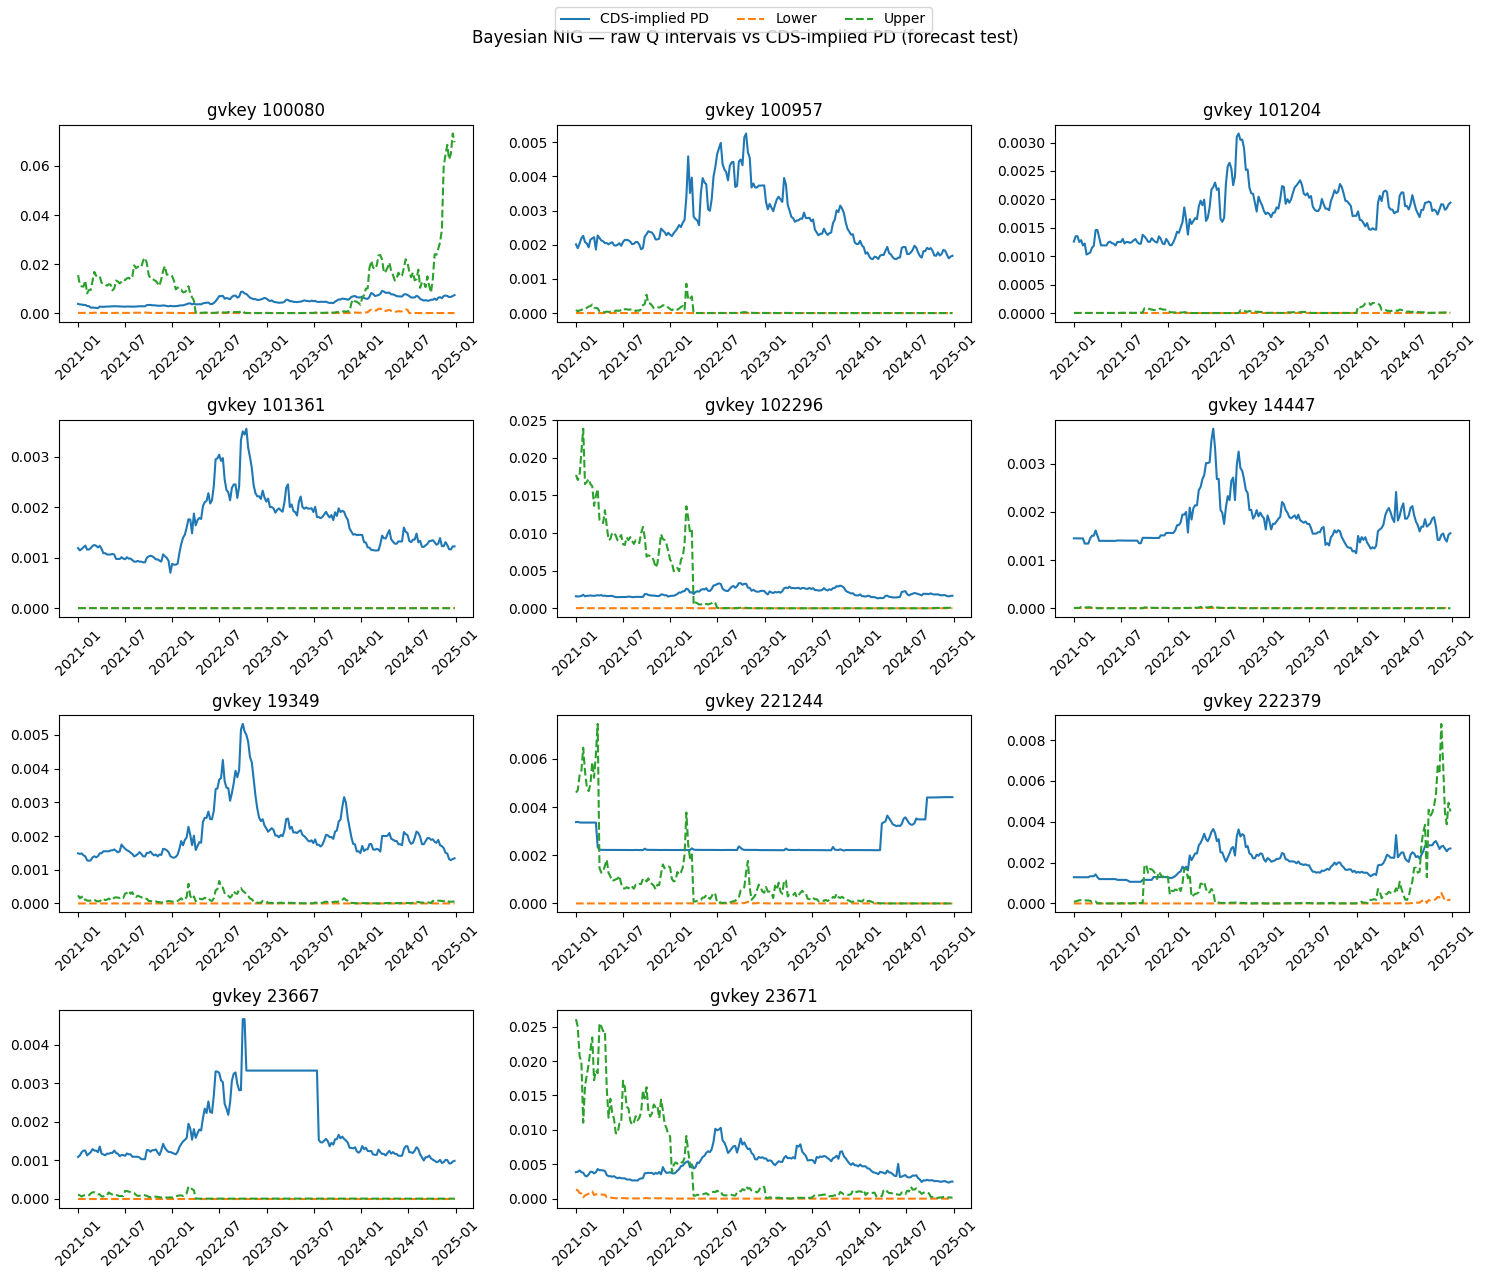

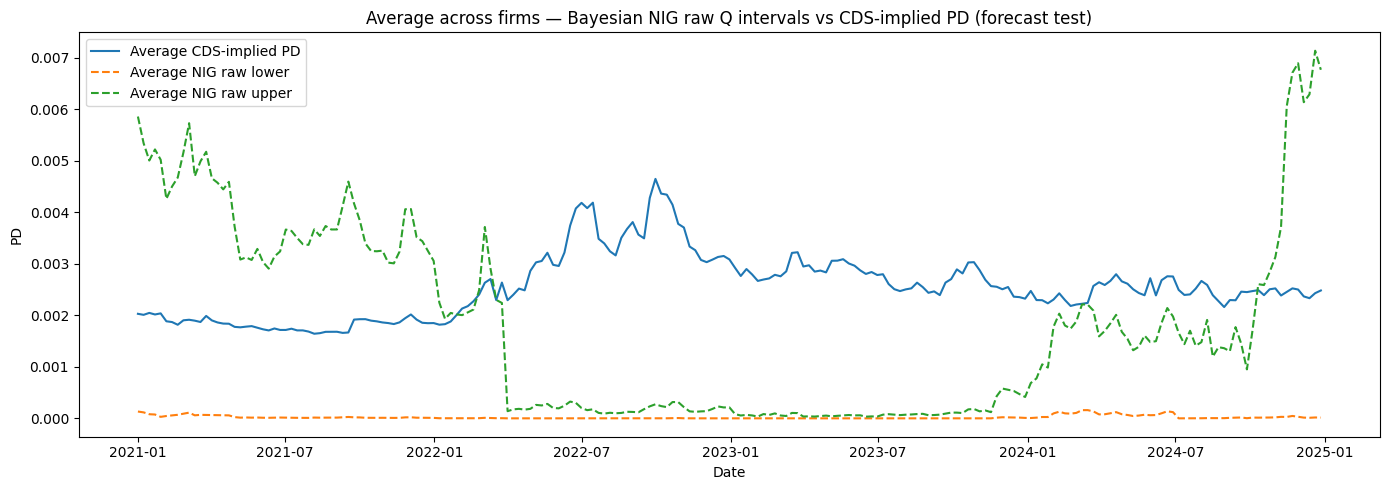

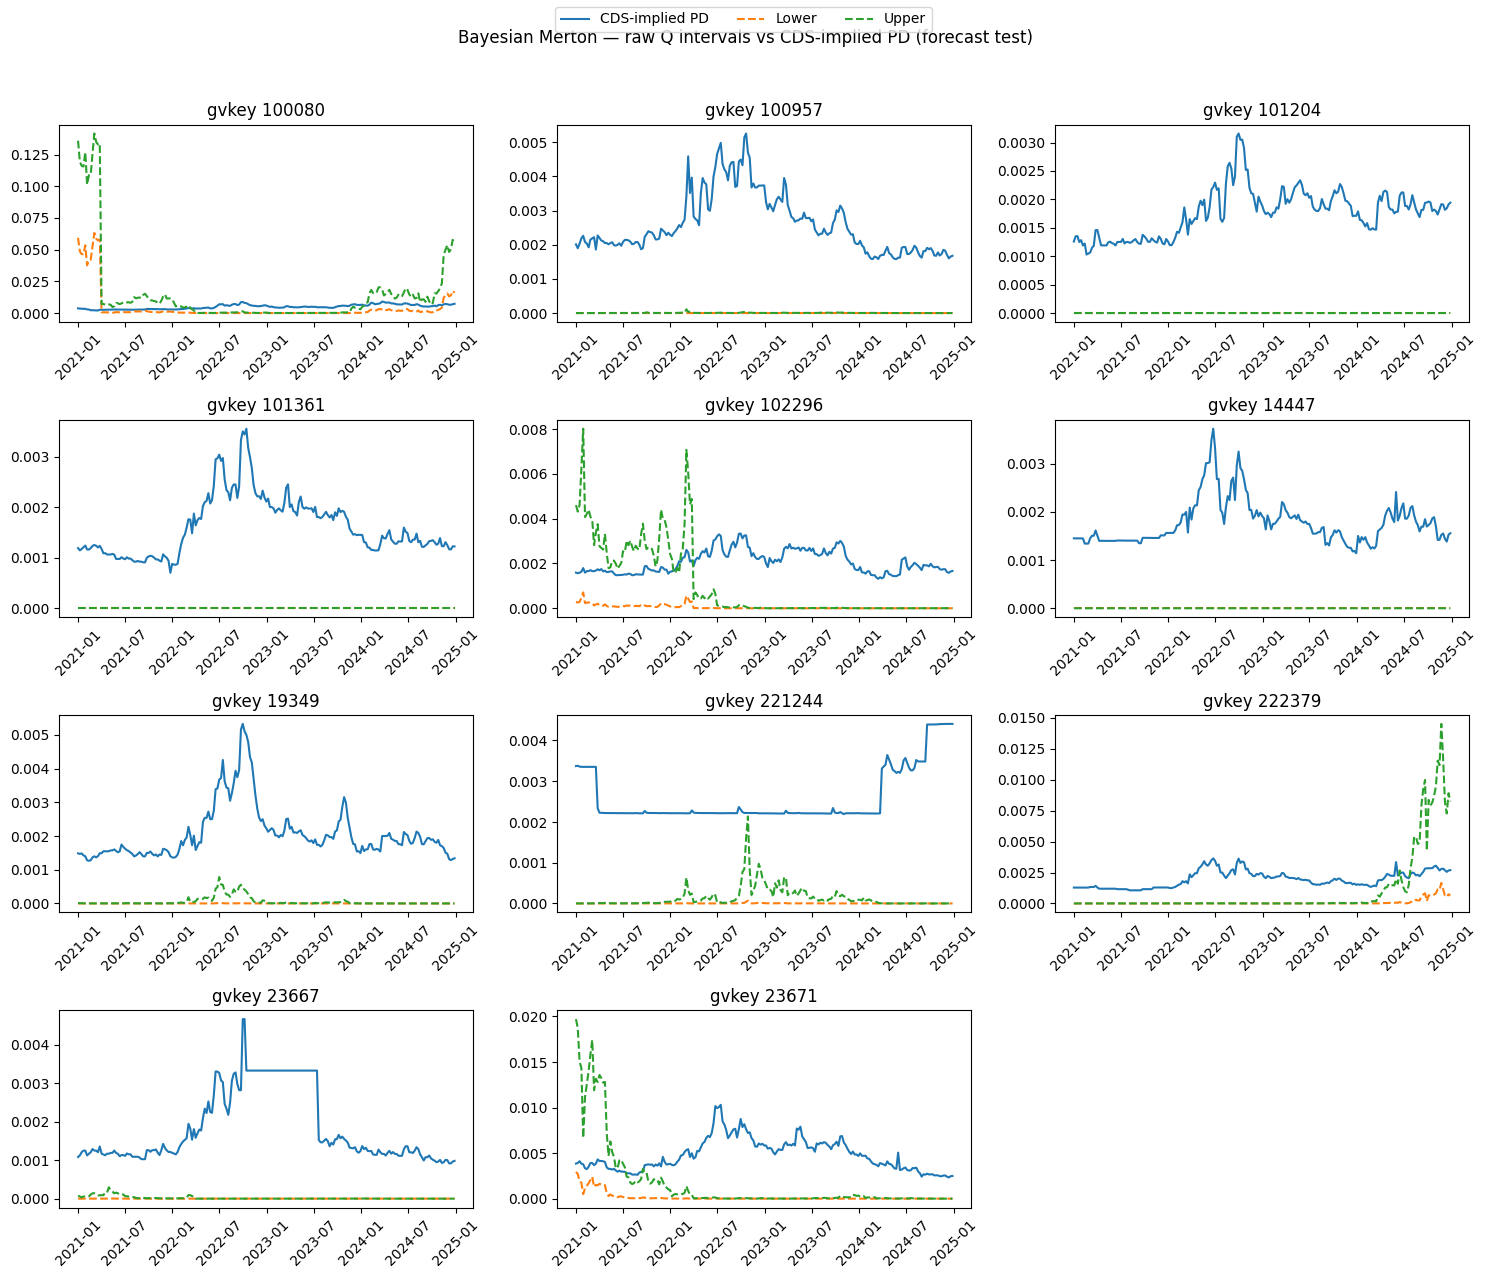

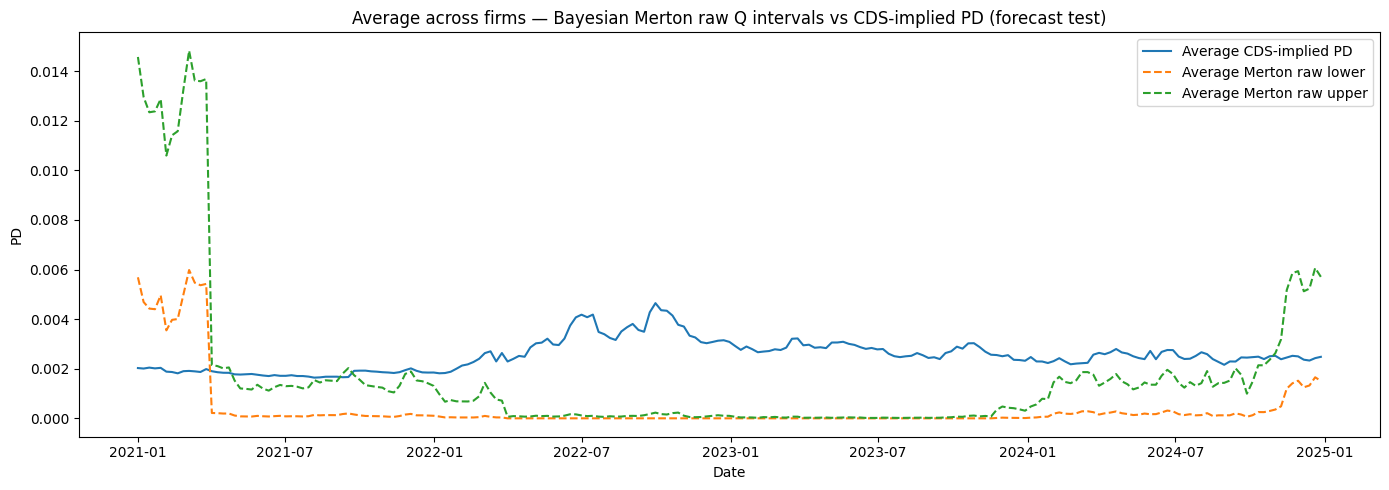

In [9]:
# Cell 9 — RAW: tests + forecast plots
variant = "raw"
show_summary_tables(variant)

lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

plot_interval_panels_by_firm(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian NIG — raw Q intervals vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    title="Average across firms — Bayesian NIG raw Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average NIG raw lower",
    hi_label="Average NIG raw upper",
)
plt.show()

plot_interval_panels_by_firm(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian Merton — raw Q intervals vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    title="Average across firms — Bayesian Merton raw Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average Merton raw lower",
    hi_label="Average Merton raw upper",
)
plt.show()


===== STANDARD : VALIDATION =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,validation,standard,1144,0.95,0.010490,0.939510,0.000029,0.051372,0.001297
1,NIG,validation,standard,1144,0.95,0.018357,0.931643,0.000058,0.052343,0.001330



===== STANDARD : FORECAST TEST =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,test,standard,2299,0.95,0.009134,0.940866,0.000049,0.037866,0.000974
1,NIG,test,standard,2299,0.95,0.015224,0.934776,0.000063,0.038011,0.000981



DM / HAC on forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,-0.000145,0.000064,-2.273231,0.023012,4,IS_standard_Merton,IS_standard_NIG,Merton,NIG,standard,test


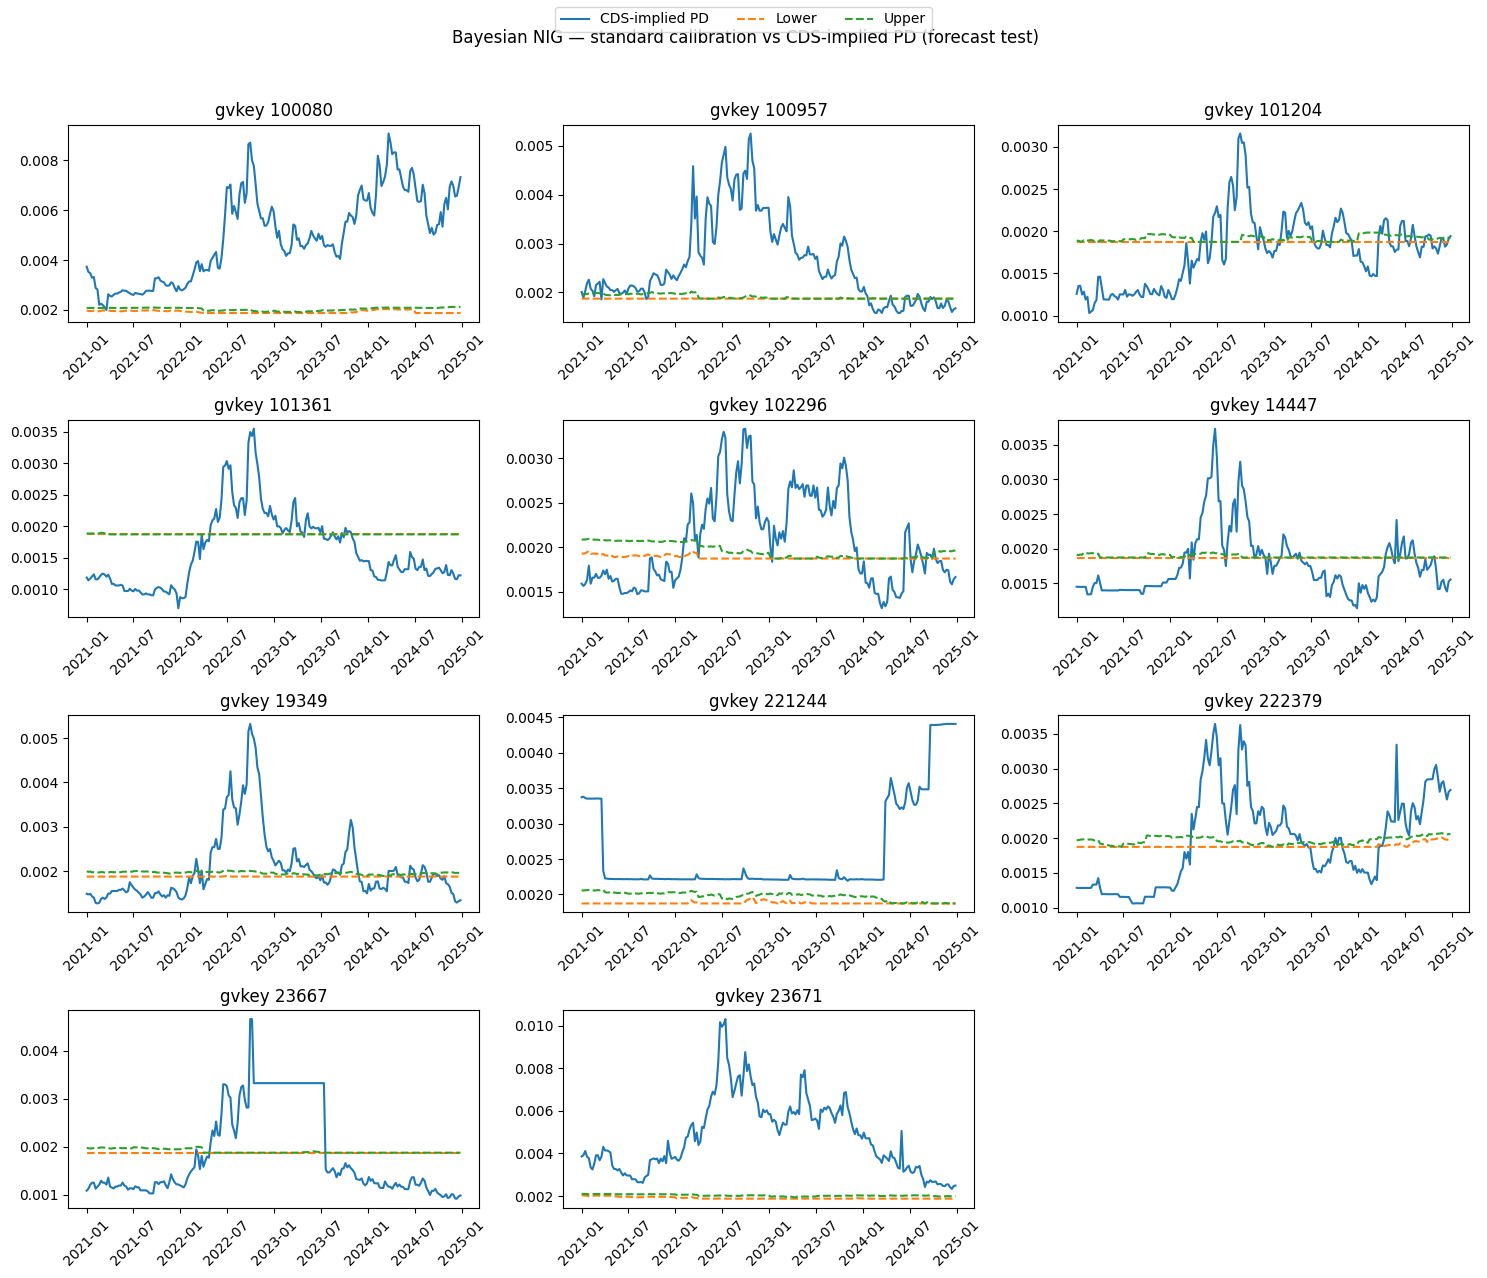

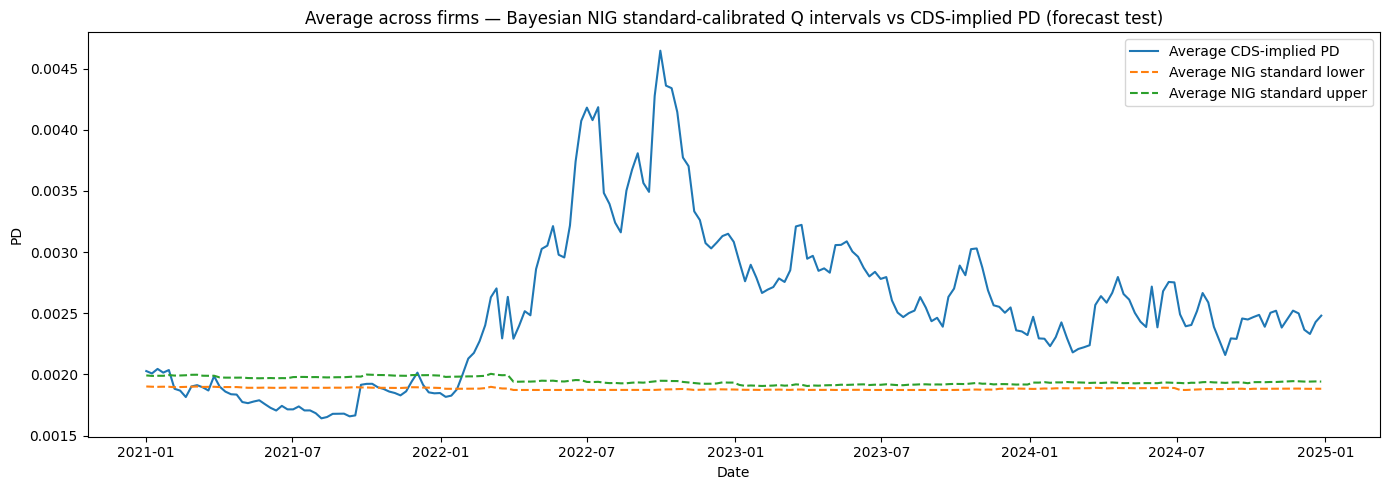

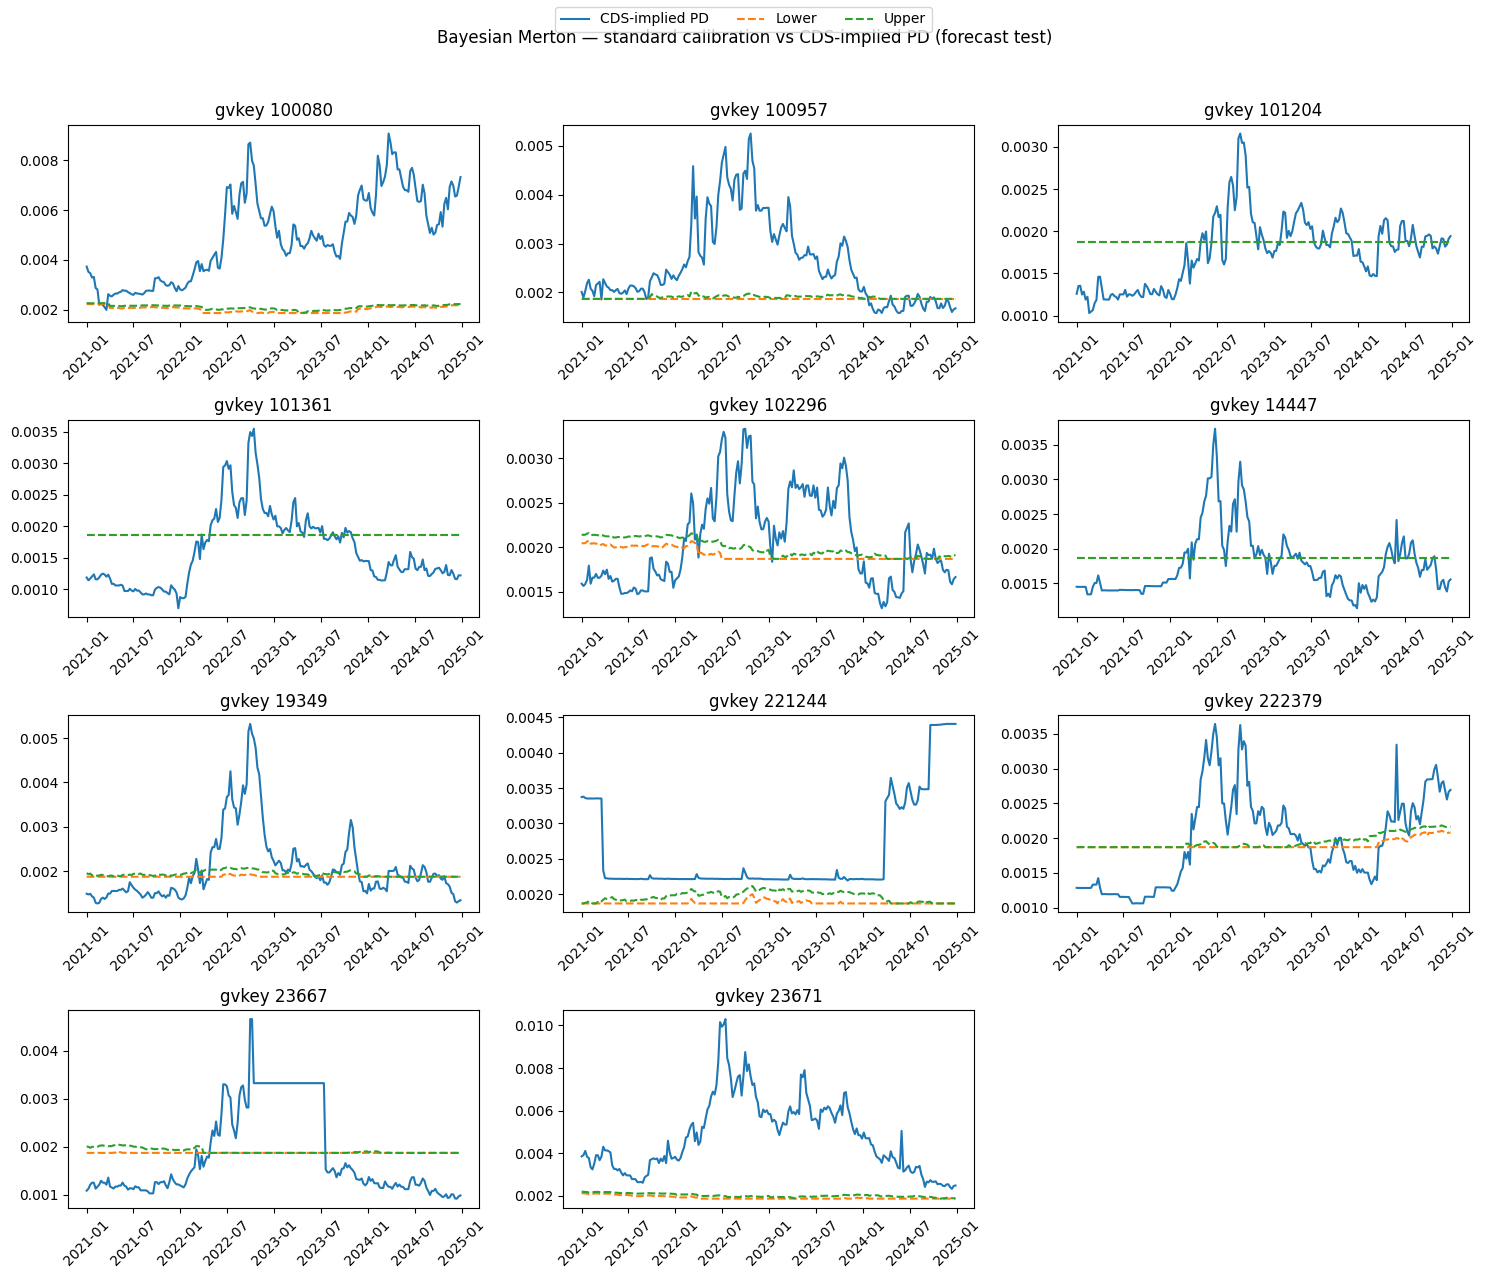

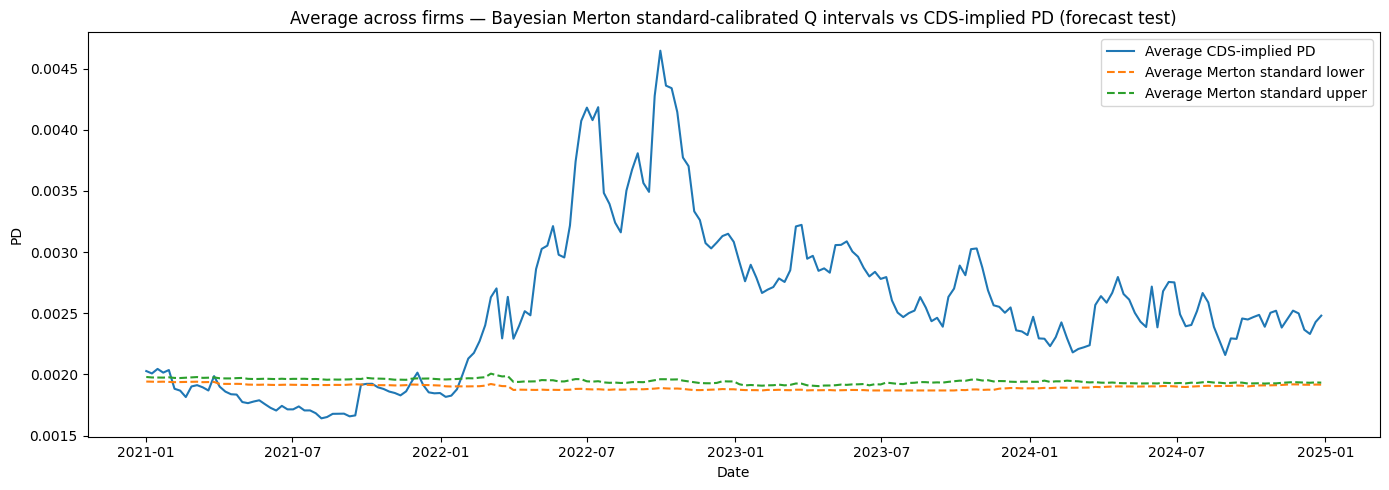

In [10]:
# Cell 10 — STANDARD calibration: tests + forecast plots
variant = "standard"
show_summary_tables(variant)

lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

plot_interval_panels_by_firm(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian NIG — standard calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    title="Average across firms — Bayesian NIG standard-calibrated Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average NIG standard lower",
    hi_label="Average NIG standard upper",
)
plt.show()

plot_interval_panels_by_firm(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian Merton — standard calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    title="Average across firms — Bayesian Merton standard-calibrated Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average Merton standard lower",
    hi_label="Average Merton standard upper",
)
plt.show()


===== K : VALIDATION =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,validation,k,1144,0.95,0.159091,0.790909,0.000573,0.046158,0.001297
1,NIG,validation,k,1144,0.95,0.212413,0.737587,0.001149,0.044697,0.001330



===== K : FORECAST TEST =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,test,k,2299,0.95,0.269682,0.680318,0.000980,0.025589,0.000974
1,NIG,test,k,2299,0.95,0.311875,0.638125,0.001251,0.025927,0.000981



DM / HAC on forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,-0.000337,0.000404,-0.835643,0.403356,4,IS_k_Merton,IS_k_NIG,Merton,NIG,k,test


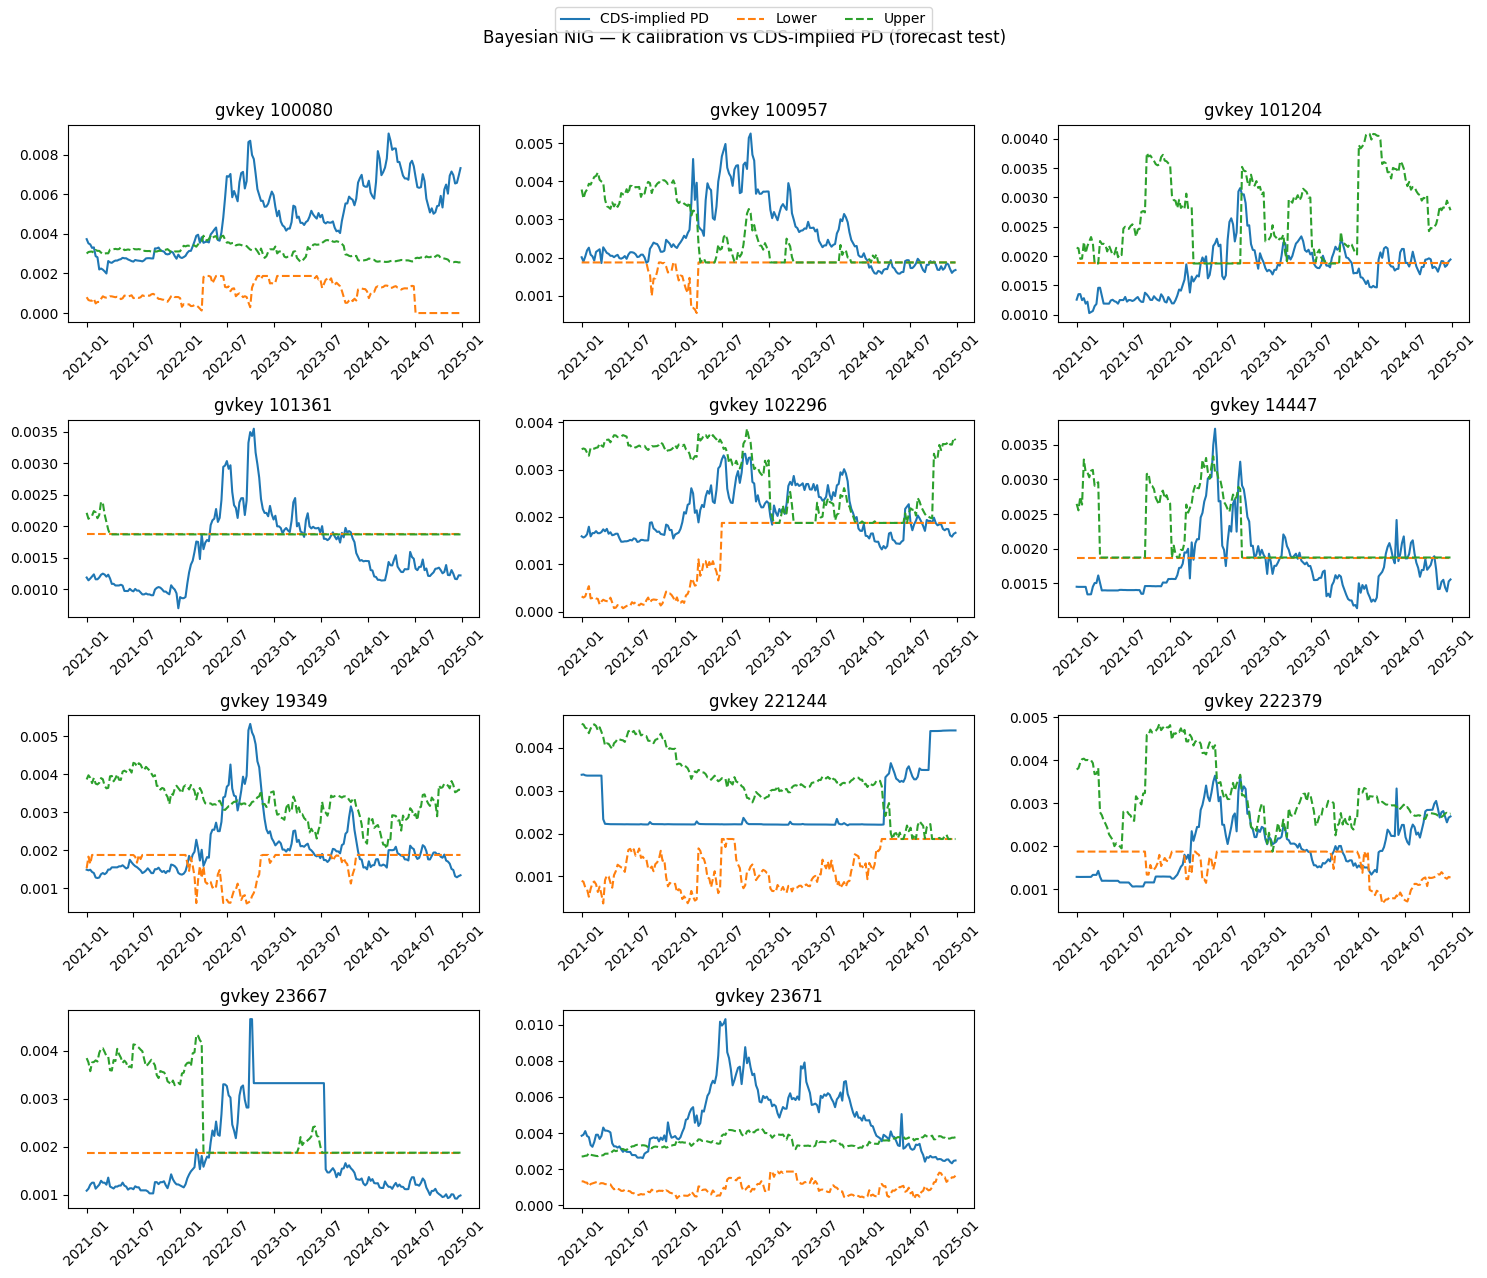

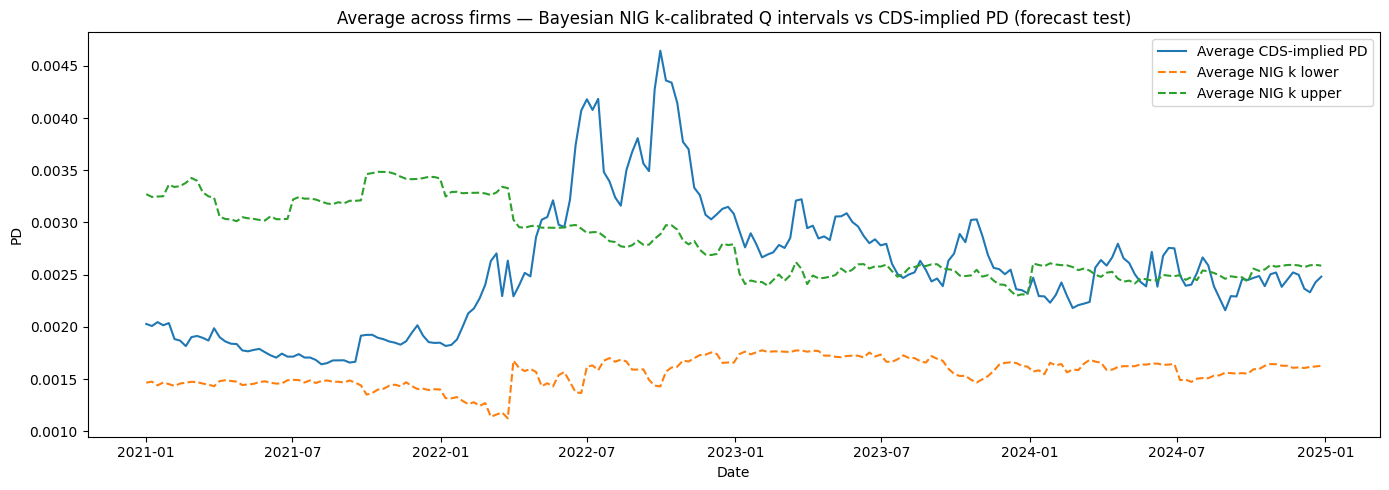

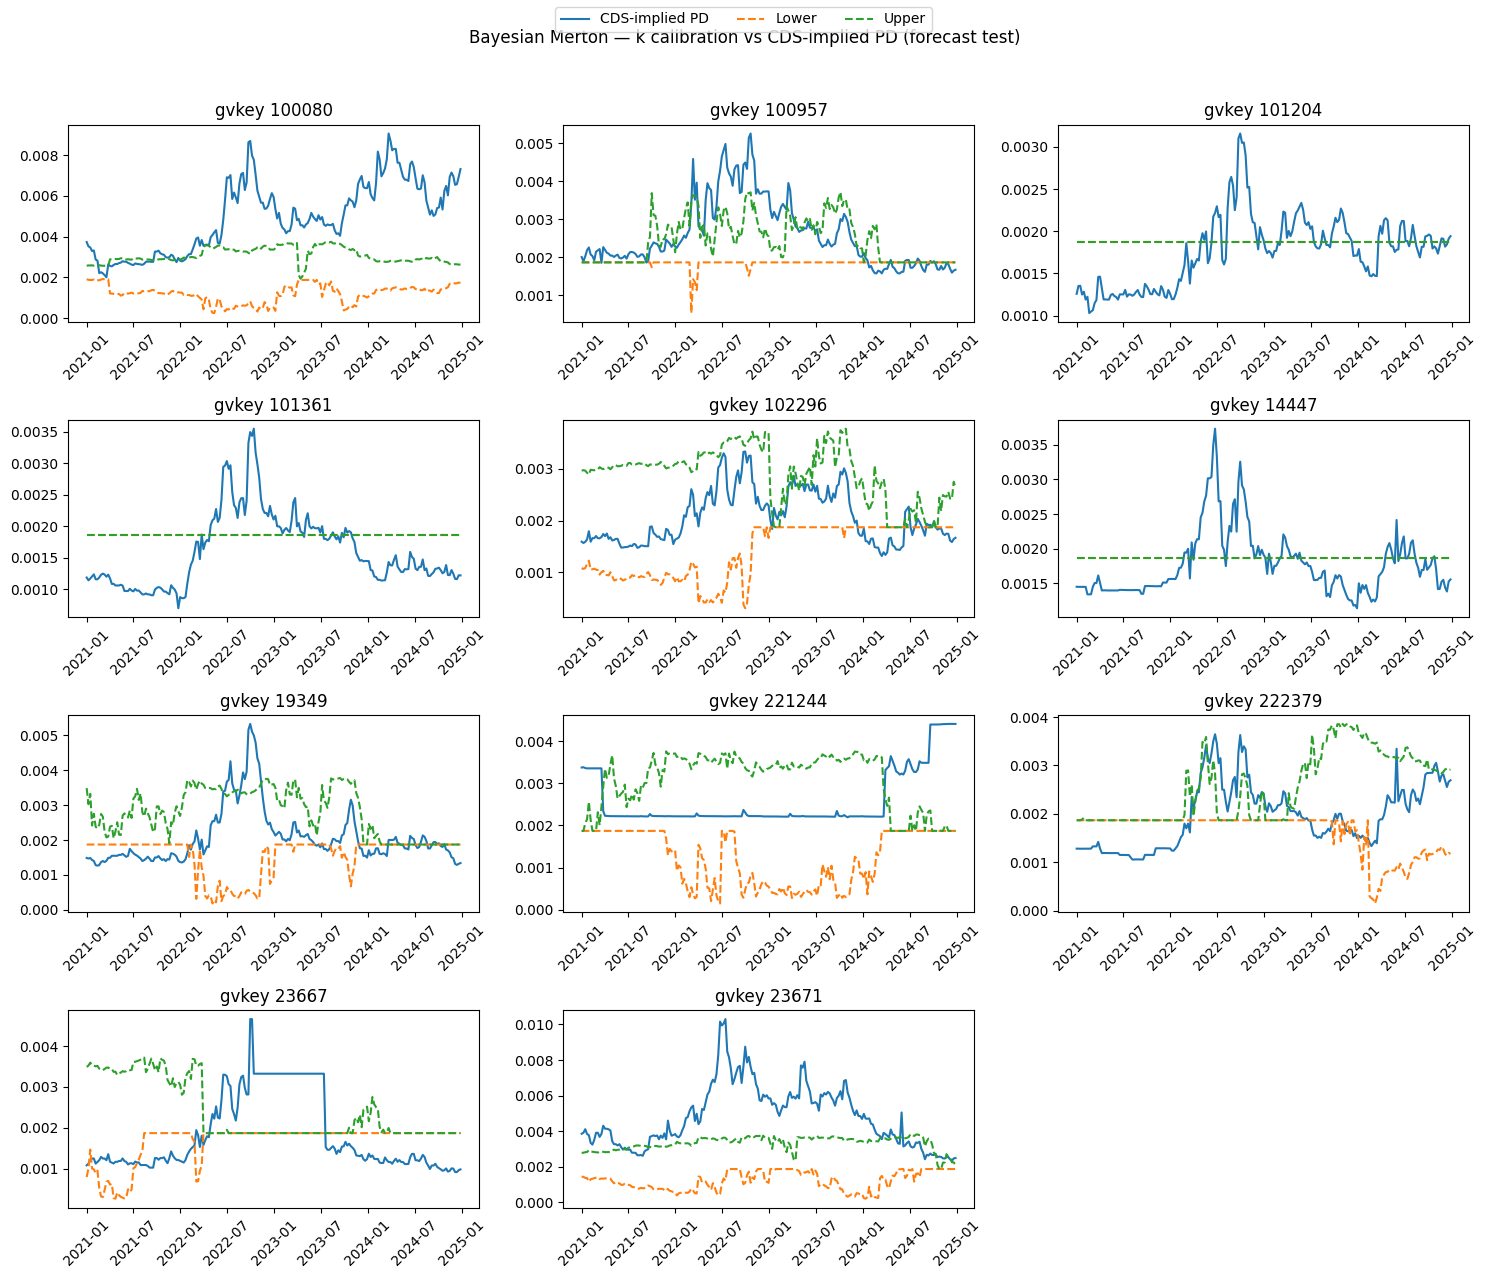

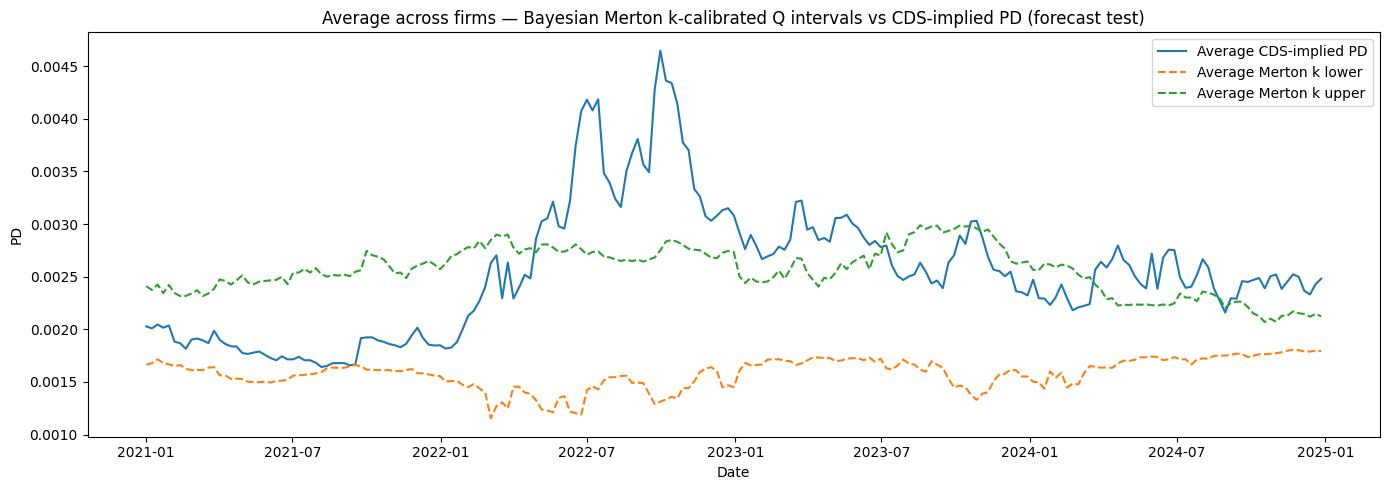

In [11]:
# Cell 11 — K calibration: tests + forecast plots
variant = "k"
show_summary_tables(variant)

lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

plot_interval_panels_by_firm(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian NIG — k calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    title="Average across firms — Bayesian NIG k-calibrated Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average NIG k lower",
    hi_label="Average NIG k upper",
)
plt.show()

plot_interval_panels_by_firm(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian Merton — k calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    title="Average across firms — Bayesian Merton k-calibrated Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average Merton k lower",
    hi_label="Average Merton k upper",
)
plt.show()


===== SHIFT : VALIDATION =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,validation,shift,1144,0.95,0.178322,0.771678,0.003976,0.047139,0.001297
1,NIG,validation,shift,1144,0.95,0.194056,0.755944,0.002458,0.044431,0.001330



===== SHIFT : FORECAST TEST =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,test,shift,2299,0.95,0.121792,0.828208,0.001030,0.031635,0.000974
1,NIG,test,shift,2299,0.95,0.165289,0.784711,0.001658,0.029438,0.000981



DM / HAC on forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,0.002198,0.000357,6.151271,7.686451e-10,4,IS_shift_Merton,IS_shift_NIG,Merton,NIG,shift,test


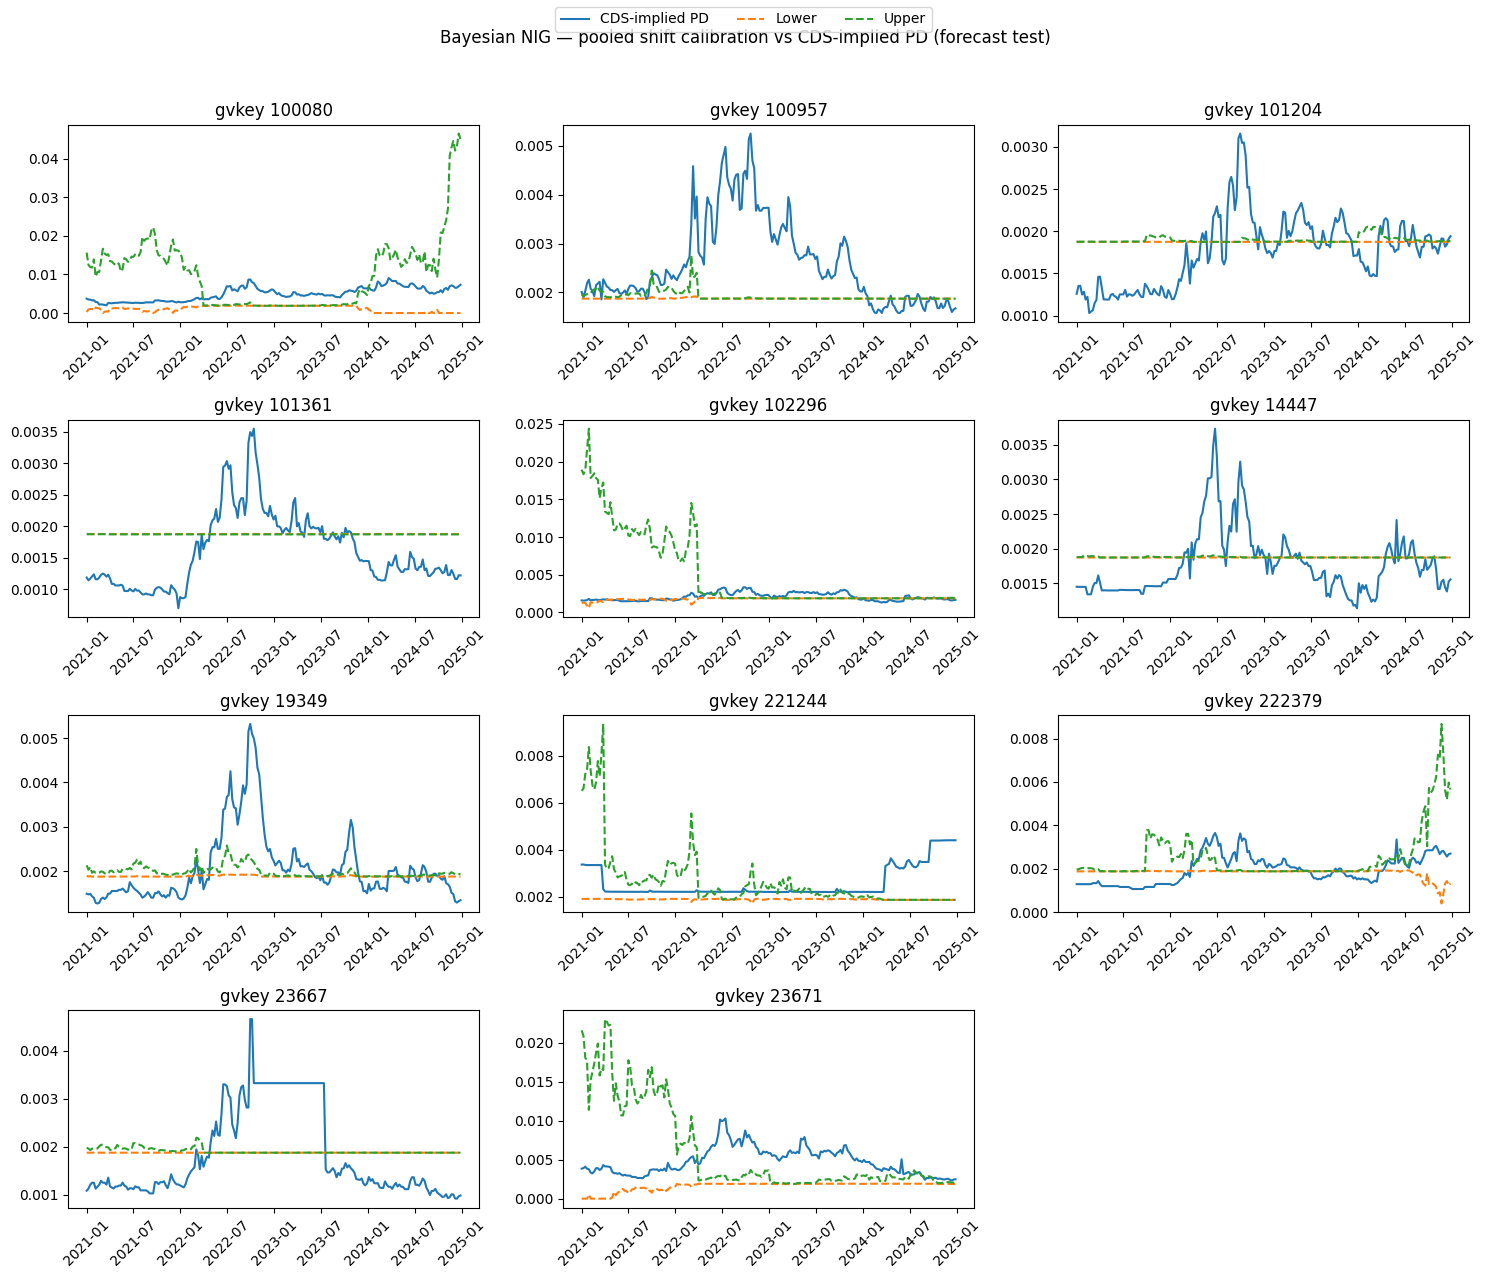

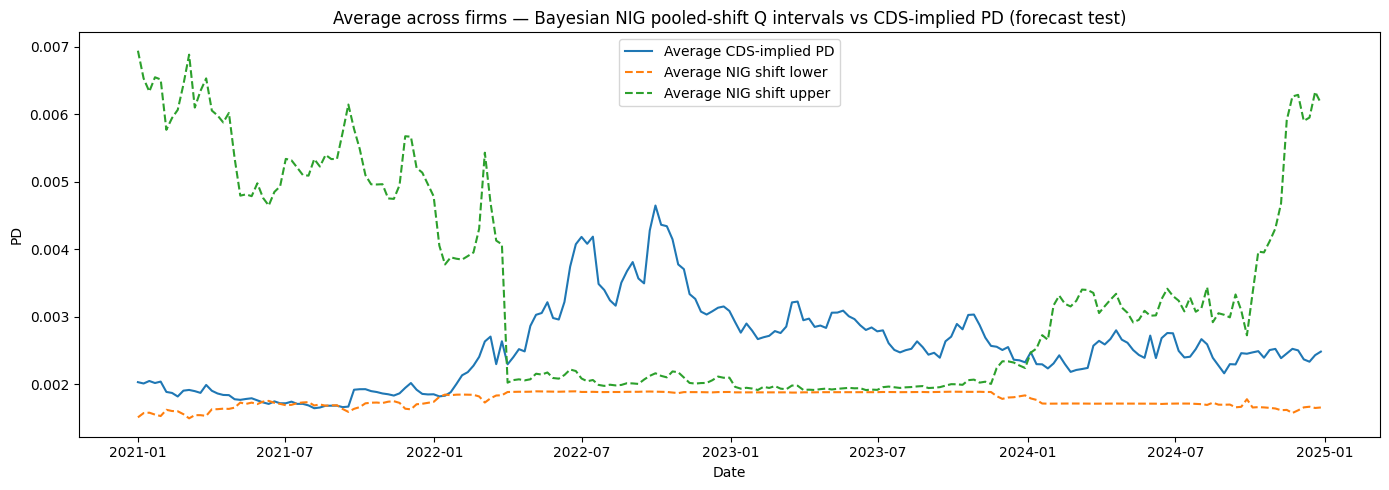

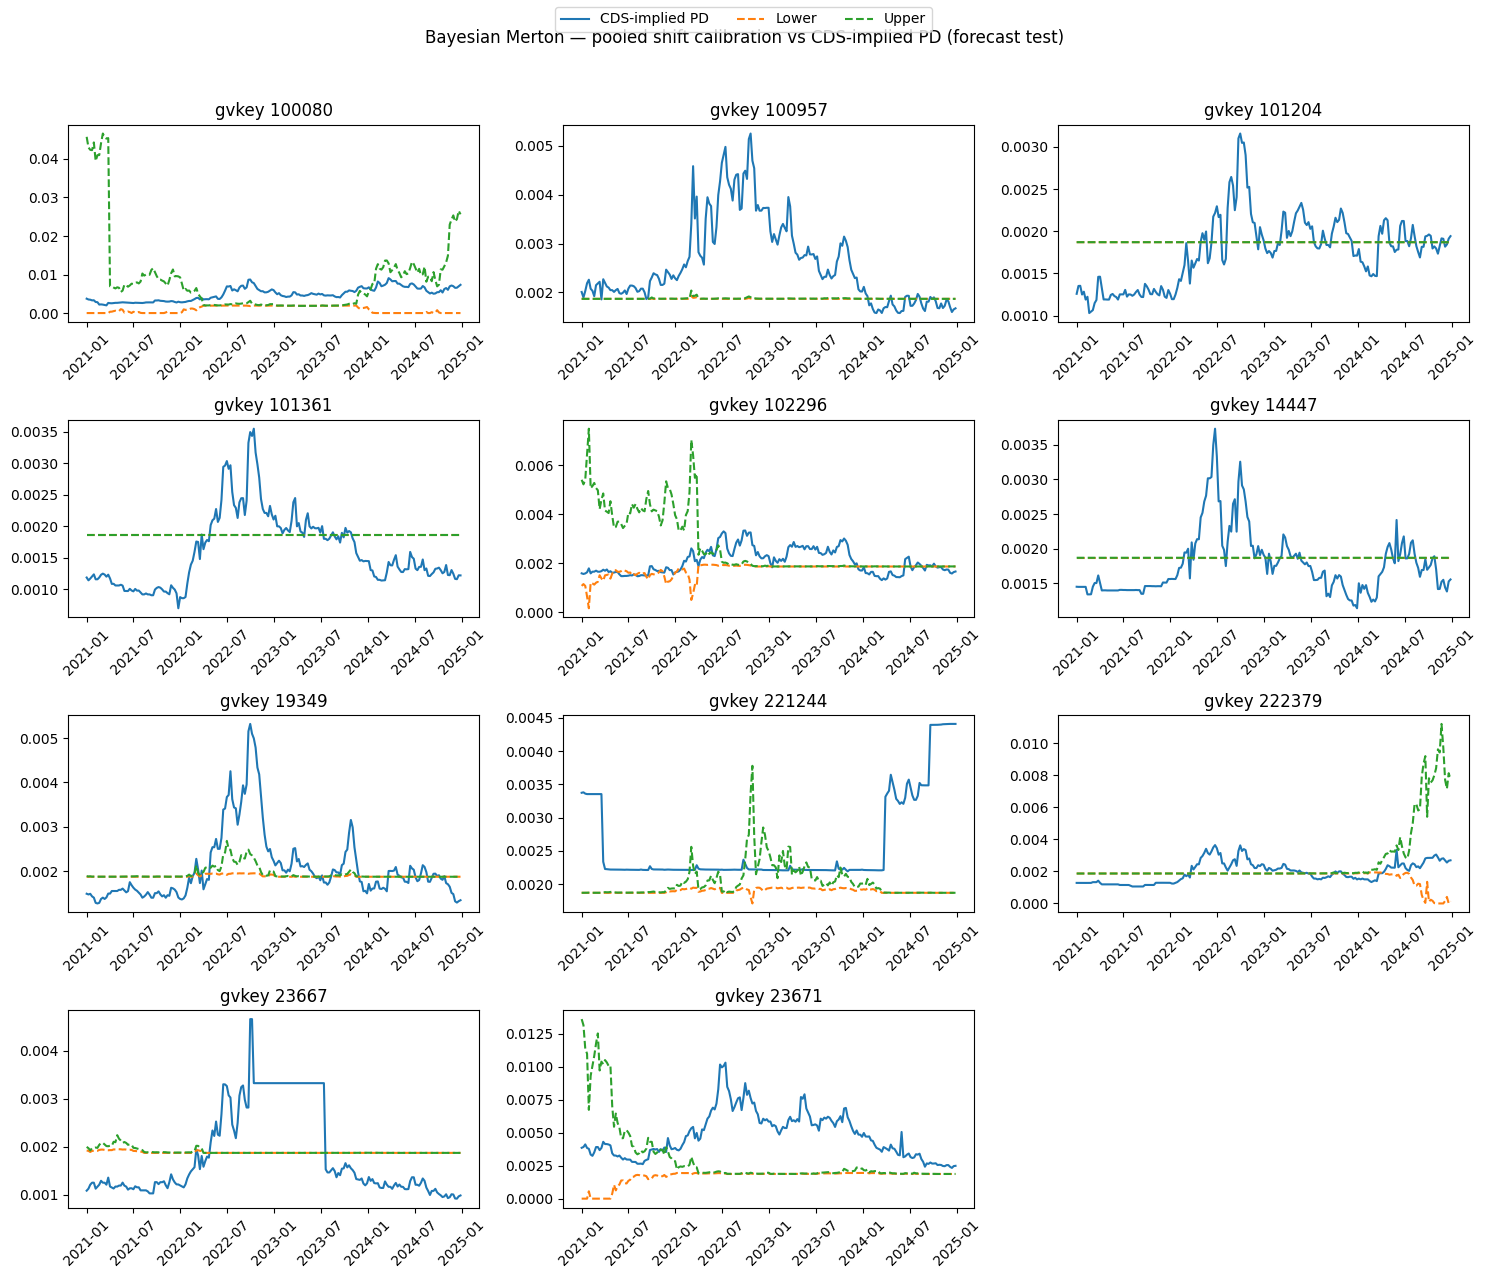

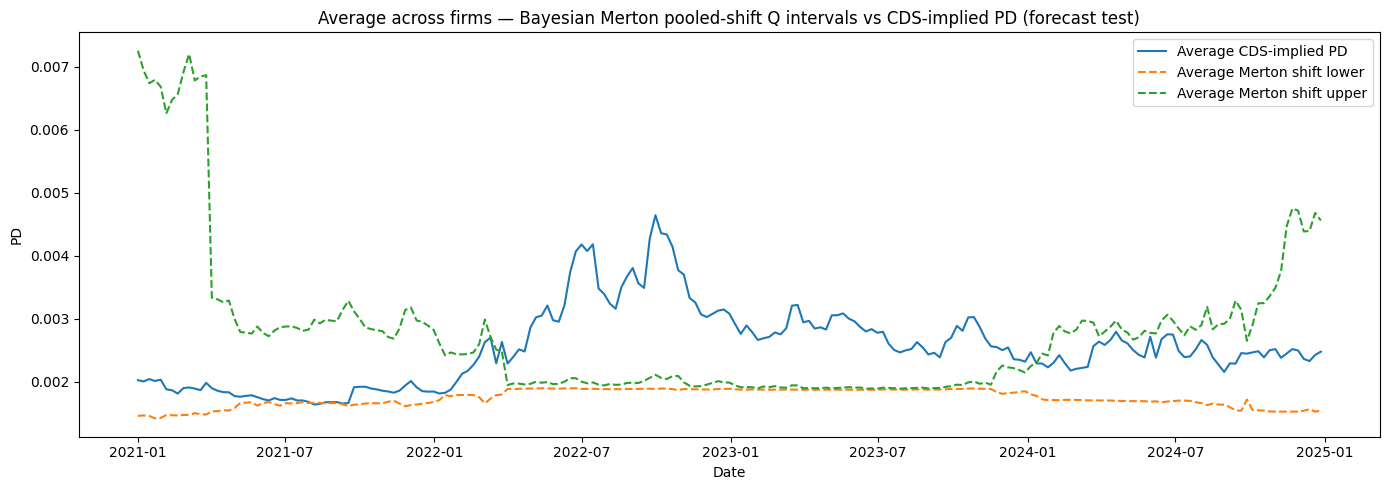

In [12]:
# Cell 12 — SHIFT calibration: tests + forecast plots
variant = "shift"
show_summary_tables(variant)

lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

plot_interval_panels_by_firm(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian NIG — pooled shift calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    title="Average across firms — Bayesian NIG pooled-shift Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average NIG shift lower",
    hi_label="Average NIG shift upper",
)
plt.show()

plot_interval_panels_by_firm(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    n_firms=N_FIRMS_PLOT,
    use_specific_firms=USE_SPECIFIC_FIRMS,
    title_suffix="Bayesian Merton — pooled shift calibration vs CDS-implied PD (forecast test)",
)
plt.show()

plot_average_interval(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    title="Average across firms — Bayesian Merton pooled-shift Q intervals vs CDS-implied PD (forecast test)",
    lo_label="Average Merton shift lower",
    hi_label="Average Merton shift upper",
)
plt.show()


===== FIRM_SHIFT : VALIDATION =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,validation,firm_shift,1144,0.95,0.053322,0.896678,0.006067,0.129921,0.005454
1,NIG,validation,firm_shift,1144,0.95,0.065559,0.884441,0.002079,2.702123,0.067662



===== FIRM_SHIFT : FORECAST TEST =====


,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,Merton,test,firm_shift,2299,0.95,0.026968,0.923032,0.001270,0.159346,0.004355
1,NIG,test,firm_shift,2299,0.95,0.058286,0.891714,0.001365,2.264790,0.056856



DM / HAC on forecast test


,T,mean,se_hac,z,p,L,score_a,score_b,label_a,label_b,variant,sample
0,209,-2.105444,0.24997,-8.422771,0.0,4,IS_firm_shift_Merton,IS_firm_shift_NIG,Merton,NIG,firm_shift,test


NIG firm-specific shift calibrators


,gvkey,n_fit_obs,used_fallback,intercept,slope,scale,eps,error_msg
0,100080,157,False,14.451056,1.490591,logit,0.000001,None
1,100957,157,False,-6.091475,-0.005936,logit,0.000001,None
2,101204,157,False,-0.034664,0.478902,logit,0.000001,None
3,101361,157,False,-6.619125,0.004051,logit,0.000001,None
4,102296,157,False,-5.882036,0.033885,logit,0.000001,None


Merton firm-specific shift calibrators


,gvkey,n_fit_obs,used_fallback,intercept,slope,scale,eps,error_msg
0,100080,157,False,-2.275704,0.291061,logit,0.000001,None
1,100957,157,False,-0.031573,0.436191,logit,0.000001,None
2,101204,157,False,-0.034664,0.478902,logit,0.000001,None
3,101361,157,False,-0.034737,0.479904,logit,0.000001,None
4,102296,157,False,-0.032855,0.453907,logit,0.000001,None


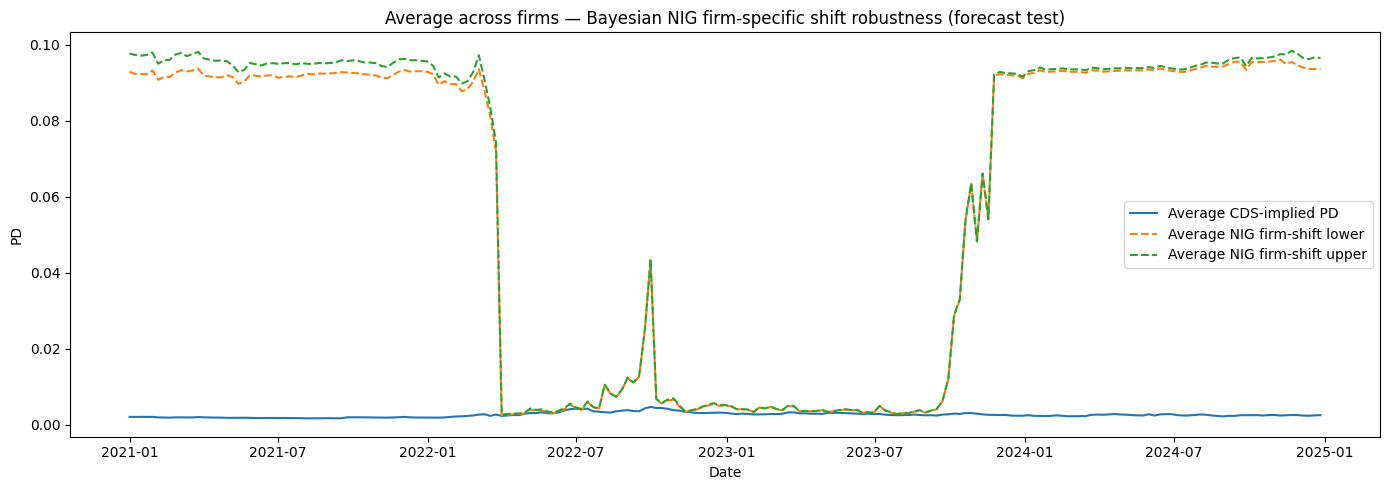

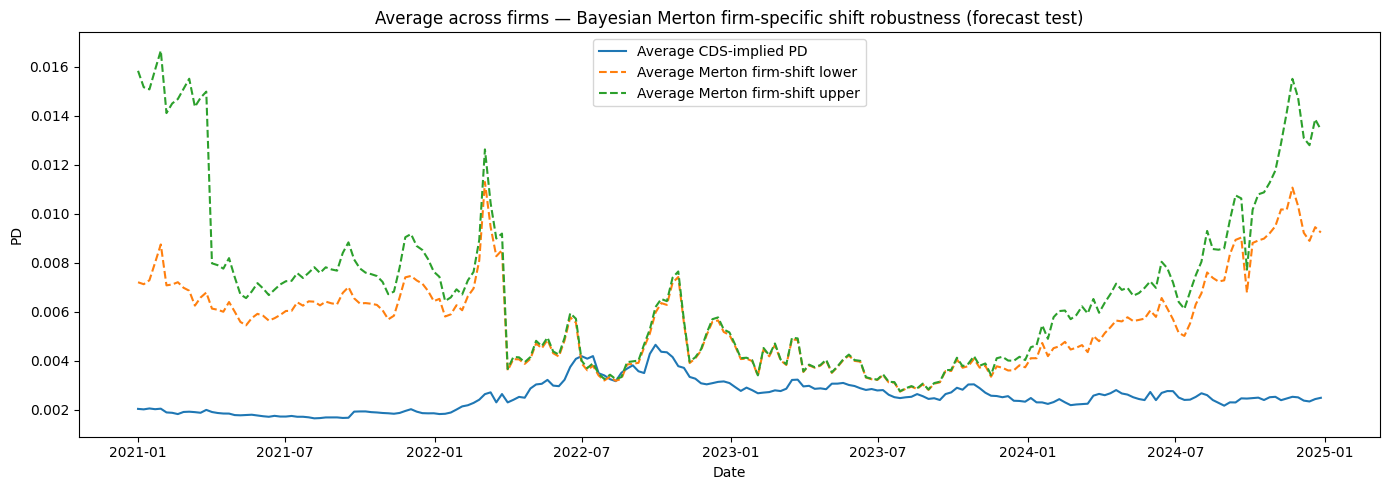

In [13]:
# Cell 13 — firm-specific shift robustness
variant = "firm_shift"
show_summary_tables(variant)

print("NIG firm-specific shift calibrators")
display(res_nig["firm_calibrator_tables"]["firm_shift"].head())

print("Merton firm-specific shift calibrators")
display(res_merton["firm_calibrator_tables"]["firm_shift"].head())

lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

plot_average_interval(
    res_nig["test_df"],
    target_col=BENCH,
    lo_col=lo_nig,
    hi_col=hi_nig,
    title="Average across firms — Bayesian NIG firm-specific shift robustness (forecast test)",
    lo_label="Average NIG firm-shift lower",
    hi_label="Average NIG firm-shift upper",
)
plt.show()

plot_average_interval(
    res_merton["test_df"],
    target_col=BENCH,
    lo_col=lo_mer,
    hi_col=hi_mer,
    title="Average across firms — Bayesian Merton firm-specific shift robustness (forecast test)",
    lo_label="Average Merton firm-shift lower",
    hi_label="Average Merton firm-shift upper",
)
plt.show()

In [14]:
# Cell 14 — chosen main variant final forecast summaries
chosen_test_rows = pd.concat(
    [
        res_nig["selected_variant_test_summary"],
        res_merton["selected_variant_test_summary"],
    ],
    ignore_index=True,
)

display(chosen_test_rows)

print("Chosen main variants:")
print("NIG   :", res_nig["selected_variant"])
print("Merton:", res_merton["selected_variant"])

,model,sample,variant,n_obs,target_coverage,empirical_coverage,coverage_gap,mean_width,mean_interval_score,mean_abs_error_med
0,NIG,test,shift,2299,0.95,0.165289,0.784711,0.001658,0.029438,0.000981
1,Merton,test,k,2299,0.95,0.269682,0.680318,0.000980,0.025589,0.000974


Chosen main variants:
NIG   : shift
Merton: k


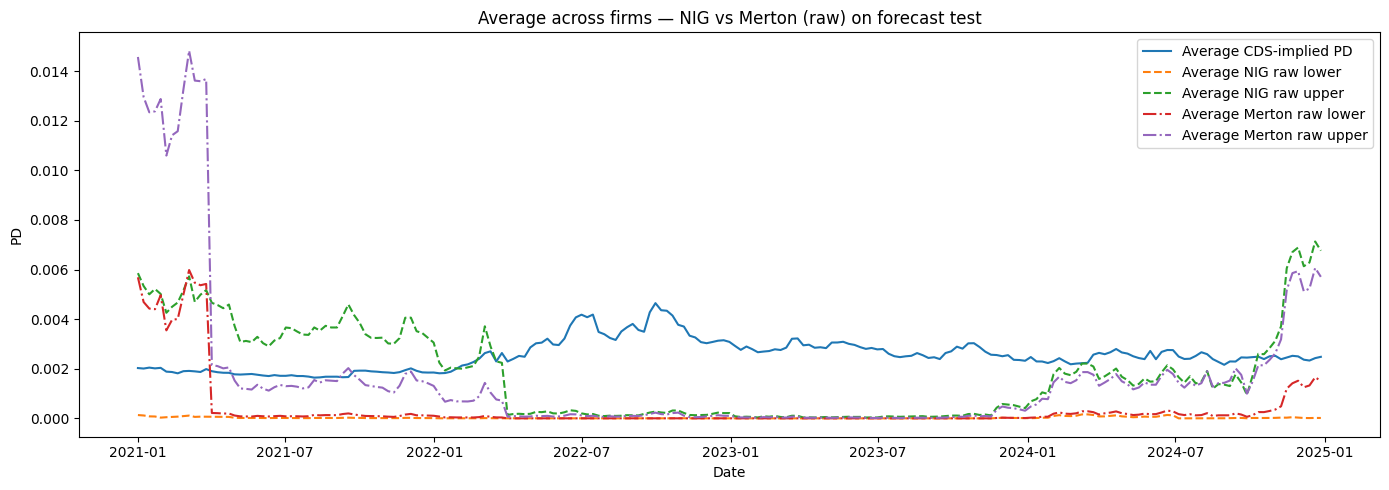

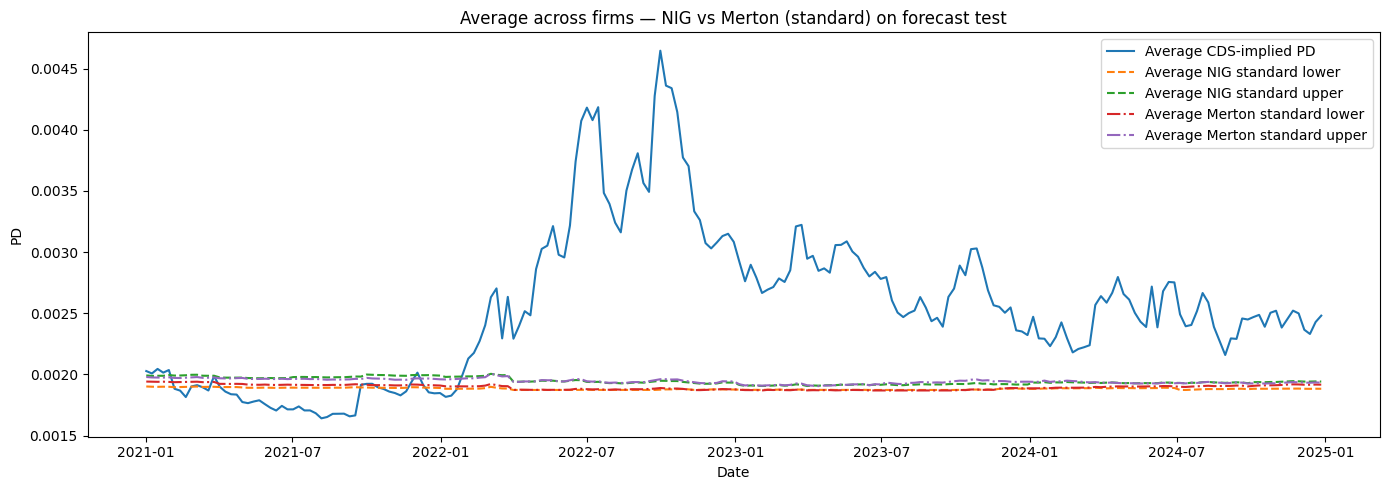

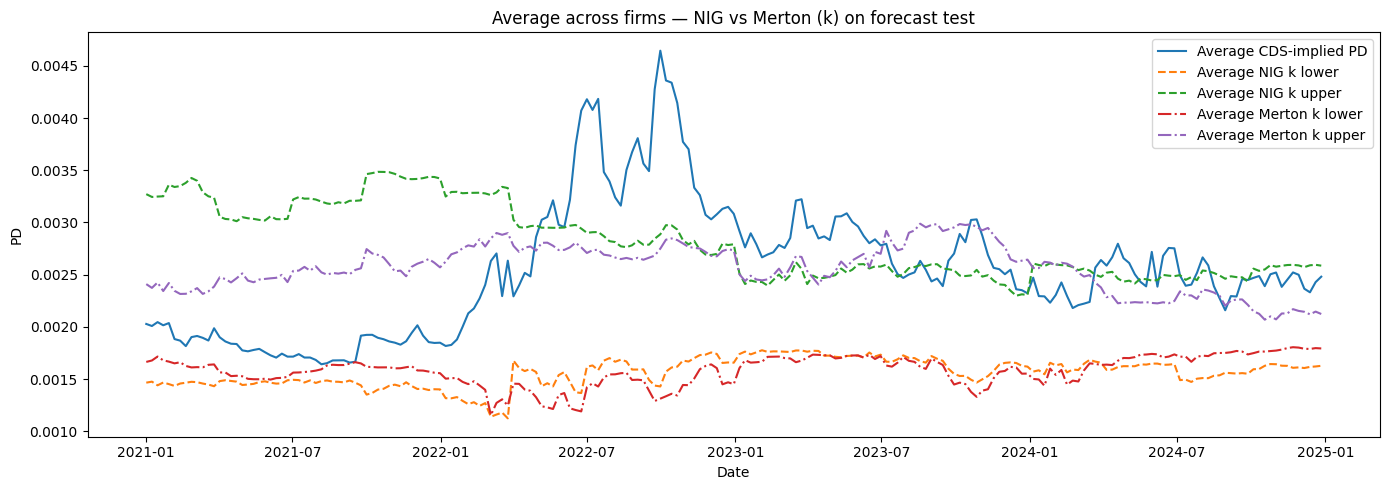

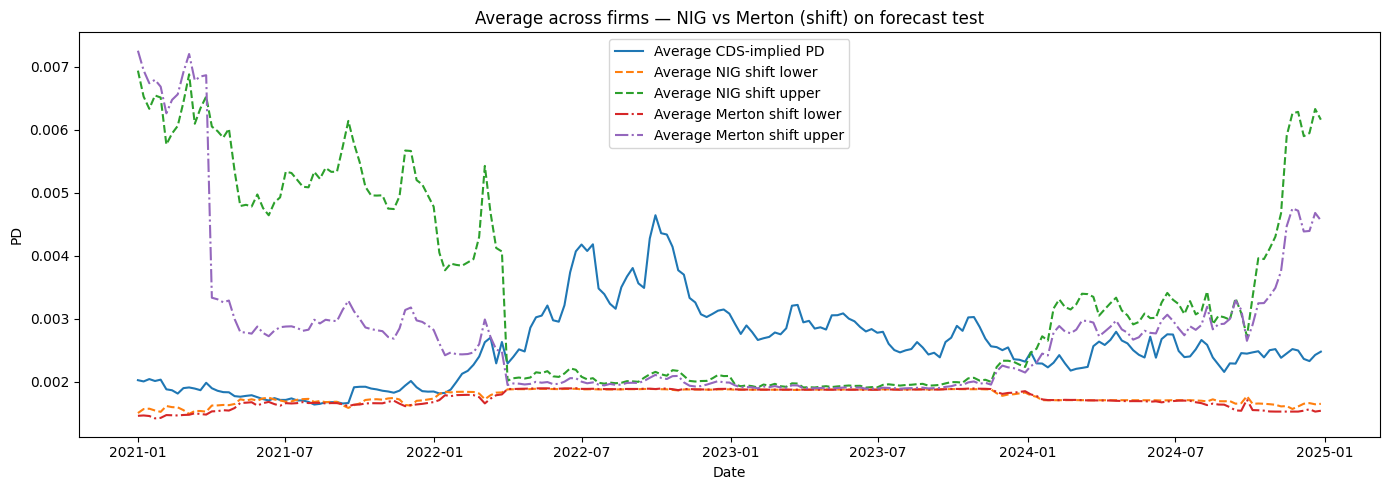

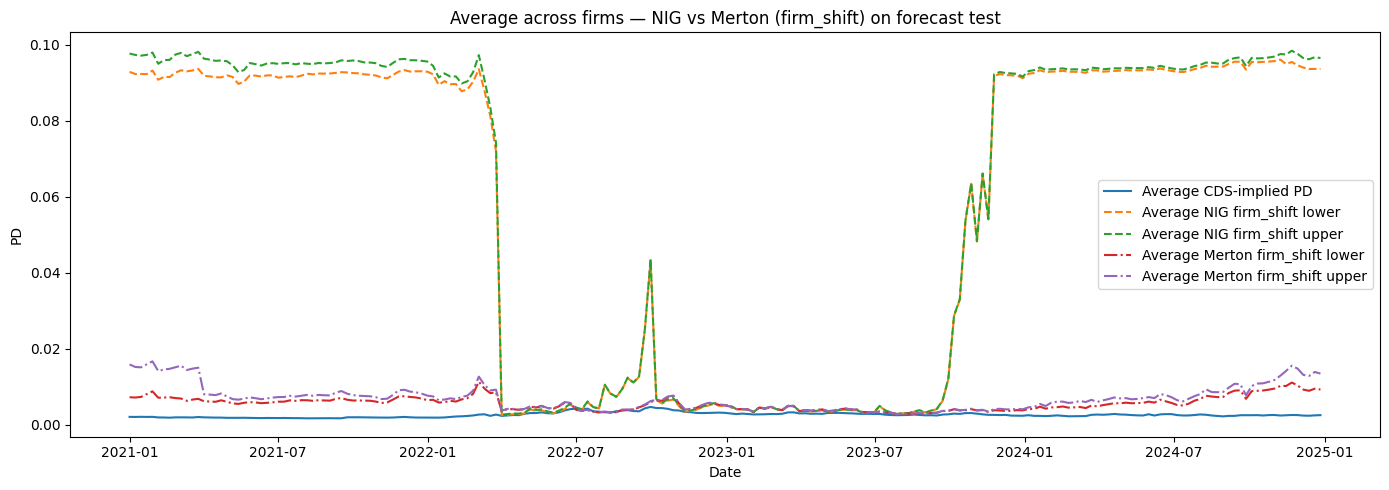

In [15]:
# Cell 15 — optional direct average comparison plot by variant
variants = ["raw", "standard", "k", "shift", "firm_shift"]

for variant in variants:
    lo_nig, _, hi_nig = cols_for_variant("NIG", variant)
    lo_mer, _, hi_mer = cols_for_variant("Merton", variant)

    avg_cmp = (
        joint_test.groupby("date", as_index=False)[
            [BENCH, lo_nig, hi_nig, lo_mer, hi_mer]
        ]
        .mean()
        .sort_values("date")
    )

    plt.figure(figsize=(14, 5))
    plt.plot(avg_cmp["date"], avg_cmp[BENCH], label="Average CDS-implied PD")
    plt.plot(avg_cmp["date"], avg_cmp[lo_nig], linestyle="--", label=f"Average NIG {variant} lower")
    plt.plot(avg_cmp["date"], avg_cmp[hi_nig], linestyle="--", label=f"Average NIG {variant} upper")
    plt.plot(avg_cmp["date"], avg_cmp[lo_mer], linestyle="-.", label=f"Average Merton {variant} lower")
    plt.plot(avg_cmp["date"], avg_cmp[hi_mer], linestyle="-.", label=f"Average Merton {variant} upper")
    plt.title(f"Average across firms — NIG vs Merton ({variant}) on forecast test")
    plt.xlabel("Date")
    plt.ylabel("PD")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
# Cell 16 — save outputs
out_nig = model_data_dir / "bayesian_nig"
out_merton = model_data_dir / "bayesian_merton_eval"
out_cmp = model_data_dir / "bayesian_interval_comparison"

out_nig.mkdir(parents=True, exist_ok=True)
out_merton.mkdir(parents=True, exist_ok=True)
out_cmp.mkdir(parents=True, exist_ok=True)

eval_nig.to_csv(out_nig / "eval_ready_bayes_nig_panel.csv", index=False)
eval_merton.to_csv(out_merton / "eval_ready_bayes_merton_panel.csv", index=False)
eval_overlap.to_csv(out_cmp / "eval_overlap_bayesian_interval_panel.csv", index=False)

res_nig["fit_df"].to_csv(out_nig / "bayes_nig_fit_all_variants.csv", index=False)
res_nig["validation_df"].to_csv(out_nig / "bayes_nig_validation_all_variants.csv", index=False)
res_nig["test_df"].to_csv(out_nig / "bayes_nig_test_all_variants.csv", index=False)
res_nig["summary_table"].to_csv(out_nig / "bayes_nig_summary_all_variants.csv", index=False)
res_nig["calibrator_table"].to_csv(out_nig / "bayes_nig_calibrators_all_variants.csv", index=False)
res_nig["selection_table"].to_csv(out_nig / "bayes_nig_selection_validation.csv", index=False)
res_nig["firm_calibrator_tables"]["firm_shift"].to_csv(out_nig / "bayes_nig_firm_shift_calibrators.csv", index=False)

res_merton["fit_df"].to_csv(out_merton / "bayes_merton_fit_all_variants.csv", index=False)
res_merton["validation_df"].to_csv(out_merton / "bayes_merton_validation_all_variants.csv", index=False)
res_merton["test_df"].to_csv(out_merton / "bayes_merton_test_all_variants.csv", index=False)
res_merton["summary_table"].to_csv(out_merton / "bayes_merton_summary_all_variants.csv", index=False)
res_merton["calibrator_table"].to_csv(out_merton / "bayes_merton_calibrators_all_variants.csv", index=False)
res_merton["selection_table"].to_csv(out_merton / "bayes_merton_selection_validation.csv", index=False)
res_merton["firm_calibrator_tables"]["firm_shift"].to_csv(out_merton / "bayes_merton_firm_shift_calibrators.csv", index=False)

summary_all.to_csv(out_cmp / "bayesian_interval_summary_all_models_variants.csv", index=False)
dm_valid.to_csv(out_cmp / "bayesian_interval_dm_validation.csv", index=False)
dm_test.to_csv(out_cmp / "bayesian_interval_dm_test.csv", index=False)
joint_valid.to_csv(out_cmp / "bayesian_interval_joint_validation_panel.csv", index=False)
joint_test.to_csv(out_cmp / "bayesian_interval_joint_test_panel.csv", index=False)
chosen_test_rows.to_csv(out_cmp / "bayesian_interval_selected_variant_test_summary.csv", index=False)

print("Saved to:")
print(" -", out_nig)
print(" -", out_merton)
print(" -", out_cmp)

Saved to:
 - ..\data\derived\bayesian_nig
 - ..\data\derived\bayesian_merton_eval
 - ..\data\derived\bayesian_interval_comparison


In [17]:
# Cell A — reload module and import the new helpers
import importlib
import pandas as pd
import numpy as np

import pd_estim_A.eval.eval_bayes as eval_bayes
from pd_estim_A.data.cds_df import get_cds_panel
importlib.reload(eval_bayes)

from pd_estim_A.eval.eval_bayes import (
    build_daily_cds_rolling_volatility,
    attach_cds_rolling_volatility_to_weekly_panel,
    add_raw_interval_widths,
    run_width_vol_model_comparison,
    run_all_width_vol_model_comparisons,
)

In [18]:
# Cell A — daily CDS panel for the width/volatility diagnostic

cds = get_cds_panel(
    project_root=Path.cwd() / "..",
    save_csv=False,
    verbose=True,
).copy()

cds["gvkey"] = cds["gvkey"].astype(str)
cds["date"] = pd.to_datetime(cds["date"], errors="coerce")
cds["cds"] = pd.to_numeric(cds["cds"], errors="coerce")

# Keep only firms that appear in the weekly comparison panel
common_gv = sorted(set(joint_test["gvkey"].astype(str).unique()) & set(cds["gvkey"].unique()))
cds = cds[cds["gvkey"].isin(common_gv)].copy()

cds = cds.sort_values(["gvkey", "date"]).reset_index(drop=True)

print("CDS rows :", len(cds))
print("CDS firms:", cds["gvkey"].nunique())
print("CDS date range:", cds["date"].min(), "->", cds["date"].max())
display(cds.head(10))

[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
[get_cds_panel] sheets read: 22 | rows parsed: 67015 | unmapped sheets: 0
CDS rows : 33220
CDS firms: 11
CDS date range: 2014-01-01 00:00:00 -> 2025-12-31 00:00:00


,gvkey,date,cds
0,100080,2014-01-01,7.39
1,100080,2014-01-02,8.05
2,100080,2014-01-03,8.05
3,100080,2014-01-06,7.96
4,100080,2014-01-07,7.88
5,100080,2014-01-08,8.03
6,100080,2014-01-09,8.11
7,100080,2014-01-10,8.11
8,100080,2014-01-13,8.11
9,100080,2014-01-14,8.11


In [19]:
# Cell B — build daily 20-day rolling CDS volatility dataframe

cds_vol_daily = build_daily_cds_rolling_volatility(
    cds,
    id_col="gvkey",
    date_col="date",
    spread_col="cds",
    window_days=20,
    min_periods=10,
    return_type="logdiff",
    out_col="cds_vol_20d_logdiff",
)

print("cds_vol_daily created")
print("Rows :", len(cds_vol_daily))
print("Firms:", cds_vol_daily["gvkey"].nunique())
print("Missing volatility share:", cds_vol_daily["cds_vol_20d_logdiff"].isna().mean())

display(cds_vol_daily.head(15))

cds_vol_daily created
Rows : 33220
Firms: 11
Missing volatility share: 0.0033112582781456954


,gvkey,date,cds,cds_vol_20d_logdiff
0,100080,2014-01-01,7.39,NaN
1,100080,2014-01-02,8.05,NaN
2,100080,2014-01-03,8.05,NaN
3,100080,2014-01-06,7.96,NaN
4,100080,2014-01-07,7.88,NaN
5,100080,2014-01-08,8.03,NaN
6,100080,2014-01-09,8.11,NaN
7,100080,2014-01-10,8.11,NaN
8,100080,2014-01-13,8.11,NaN
9,100080,2014-01-14,8.11,NaN


In [20]:
# Cell D — attach daily-built CDS volatility to the weekly joint test panel

left = joint_test.copy()
left["gvkey"] = left["gvkey"].astype(str)
left["date"] = pd.to_datetime(left["date"], errors="coerce")
left = left.sort_values(["date", "gvkey"]).reset_index(drop=True)

right = cds_vol_daily[["gvkey", "date", "cds_vol_20d_logdiff"]].copy()
right["gvkey"] = right["gvkey"].astype(str)
right["date"] = pd.to_datetime(right["date"], errors="coerce")
right = right.sort_values(["date", "gvkey"]).reset_index(drop=True)

widthvol_test = pd.merge_asof(
    left,
    right,
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

widthvol_test = add_raw_interval_widths(widthvol_test)

cols_show = [
    "gvkey", "date", "cds", "cds_vol_20d_logdiff",
    "W_Q_NIG_raw", "W_Q_Merton_raw",
    "W_P_NIG_raw", "W_P_Merton_raw",
]
cols_show = [c for c in cols_show if c in widthvol_test.columns]

display(widthvol_test[cols_show].head(10))

print("Rows:", len(widthvol_test))
print("Firms:", widthvol_test["gvkey"].nunique())
print("Missing CDSVol20d share:", widthvol_test["cds_vol_20d_logdiff"].isna().mean())

,gvkey,date,cds,cds_vol_20d_logdiff,W_Q_NIG_raw,W_Q_Merton_raw,W_P_NIG_raw,W_P_Merton_raw
0,100080,2021-01-01,22.44,0.023257,0.015346,7.657091e-02,1.189613e-01,2.862521e-01
1,100957,2021-01-01,12.07,0.027275,0.000090,1.909520e-09,1.443859e-05,3.596173e-11
2,101204,2021-01-01,7.55,0.025673,0.000002,2.613005e-07,6.157056e-06,1.830527e-06
3,101361,2021-01-01,7.14,0.015518,0.000002,6.316156e-13,8.668858e-07,8.994622e-13
4,102296,2021-01-01,9.55,0.017961,0.017695,4.318531e-03,4.433930e-02,9.723620e-03
5,14447,2021-01-01,8.72,0.000512,0.000006,2.998542e-10,1.567190e-07,3.219516e-12
6,19349,2021-01-01,8.92,0.017632,0.000240,1.375214e-05,3.344558e-04,1.631864e-04
7,221244,2021-01-01,20.27,0.000741,0.004597,7.008667e-07,3.099006e-03,4.714620e-07
8,222379,2021-01-01,7.71,0.025167,0.000091,3.111432e-07,1.010469e-04,3.750787e-07
9,23667,2021-01-01,6.49,0.026481,0.000104,7.474891e-05,1.046723e-03,2.148744e-04


Rows: 2299
Firms: 11
Missing CDSVol20d share: 0.0


In [21]:
# Cell F — Q-width diagnostic: NIG vs Merton

diag_q = run_width_vol_model_comparison(
    widthvol_test,
    width_col_a="W_Q_NIG_raw",
    width_col_b="W_Q_Merton_raw",
    vol_col="cds_vol_20d_logdiff",
    label_a="NIG",
    label_b="Merton",
    method="pearson",
    min_obs=10,
    alternative="two-sided",
)

print("Q-width paired Fisher-z test")
display(diag_q["test_table"])

print("Firm-level Q correlations")
display(diag_q["paired_corrs"].sort_values("gvkey").reset_index(drop=True))

Q-width paired Fisher-z test


,label_a,label_b,alternative,n_firms,mean_corr_a,median_corr_a,positive_share_a,mean_corr_b,median_corr_b,positive_share_b,mean_diff_fisher_z,t_stat,p_value_t,wilcoxon_stat,p_value_wilcoxon,width_col_a,width_col_b,vol_col,corr_method,min_obs
0,NIG,Merton,two-sided,11,-0.024289,-0.023212,0.363636,0.016382,0.002318,0.545455,-0.042464,-1.858386,0.09276,16.0,0.147461,W_Q_NIG_raw,W_Q_Merton_raw,cds_vol_20d_logdiff,pearson,10


Firm-level Q correlations


,gvkey,corr_a,fisher_z_a,n_obs_a,corr_b,fisher_z_b,n_obs_b
0,100080,-0.102693,-0.103057,209,0.044364,0.044393,209
1,100957,0.283137,0.291089,209,0.335744,0.349288,209
2,101204,-0.023212,-0.023216,209,0.052755,0.052804,209
3,101361,-0.229364,-0.233518,209,-0.186343,-0.188546,209
4,102296,-0.134298,-0.135114,209,-0.067358,-0.067460,209
5,14447,0.091971,0.092231,209,0.007590,0.007591,209
6,19349,0.153482,0.154705,209,0.318852,0.330368,209
7,221244,-0.057315,-0.057378,209,-0.041208,-0.041231,209
8,222379,0.033425,0.033437,209,0.002318,0.002318,209
9,23667,-0.268770,-0.275538,209,-0.255469,-0.261255,209


In [22]:
# Cell G — P-width diagnostic: NIG vs Merton

diag_p = run_width_vol_model_comparison(
    widthvol_test,
    width_col_a="W_P_NIG_raw",
    width_col_b="W_P_Merton_raw",
    vol_col="cds_vol_20d_logdiff",
    label_a="NIG",
    label_b="Merton",
    method="pearson",
    min_obs=10,
    alternative="two-sided",
)

print("P-width paired Fisher-z test")
display(diag_p["test_table"])

print("Firm-level P correlations")
display(diag_p["paired_corrs"].sort_values("gvkey").reset_index(drop=True))

P-width paired Fisher-z test


,label_a,label_b,alternative,n_firms,mean_corr_a,median_corr_a,positive_share_a,mean_corr_b,median_corr_b,positive_share_b,mean_diff_fisher_z,t_stat,p_value_t,wilcoxon_stat,p_value_wilcoxon,width_col_a,width_col_b,vol_col,corr_method,min_obs
0,NIG,Merton,two-sided,11,0.039888,0.020276,0.545455,-0.003801,0.007999,0.545455,0.046947,1.002146,0.339906,28.0,0.700195,W_P_NIG_raw,W_P_Merton_raw,cds_vol_20d_logdiff,pearson,10


Firm-level P correlations


,gvkey,corr_a,fisher_z_a,n_obs_a,corr_b,fisher_z_b,n_obs_b
0,100080,-0.026734,-0.026740,209,0.007999,0.008000,209
1,100957,0.333057,0.346263,209,0.158325,0.159668,209
2,101204,0.055115,0.055171,209,0.054819,0.054874,209
3,101361,-0.259388,-0.265452,209,-0.196980,-0.199589,209
4,102296,-0.046674,-0.046708,209,0.016184,0.016186,209
5,14447,0.425697,0.454629,209,-0.002252,-0.002252,209
6,19349,0.294418,0.303397,209,0.229292,0.233443,209
7,221244,-0.056169,-0.056228,209,-0.056837,-0.056898,209
8,222379,0.042034,0.042059,209,0.068948,0.069058,209
9,23667,-0.342868,-0.357339,209,-0.286457,-0.294702,209


In [23]:
# Cell F — compact combined summary table
diag_all = run_all_width_vol_model_comparisons(
    widthvol_test,
    vol_col="cds_vol_20d_logdiff",
    method="pearson",
    min_obs=20,
    alternative="two-sided",
)

display(diag_all["summary_table"])

,label_a,label_b,alternative,n_firms,mean_corr_a,median_corr_a,positive_share_a,mean_corr_b,median_corr_b,positive_share_b,...,t_stat,p_value_t,wilcoxon_stat,p_value_wilcoxon,width_col_a,width_col_b,vol_col,corr_method,min_obs,width_family
0,NIG,Merton,two-sided,11,-0.024289,-0.023212,0.363636,0.016382,0.002318,0.545455,...,-1.858386,0.092760,16.0,0.147461,W_Q_NIG_raw,W_Q_Merton_raw,cds_vol_20d_logdiff,pearson,20,Q
1,NIG,Merton,two-sided,11,0.039888,0.020276,0.545455,-0.003801,0.007999,0.545455,...,1.002146,0.339906,28.0,0.700195,W_P_NIG_raw,W_P_Merton_raw,cds_vol_20d_logdiff,pearson,20,P


In [24]:
# Cell G — optional robustness: Spearman instead of Pearson
diag_all_spearman = run_all_width_vol_model_comparisons(
    widthvol_test,
    vol_col="cds_vol_20d_logdiff",
    method="spearman",
    min_obs=20,
    alternative="two-sided",
)

display(diag_all_spearman["summary_table"])

,label_a,label_b,alternative,n_firms,mean_corr_a,median_corr_a,positive_share_a,mean_corr_b,median_corr_b,positive_share_b,...,t_stat,p_value_t,wilcoxon_stat,p_value_wilcoxon,width_col_a,width_col_b,vol_col,corr_method,min_obs,width_family
0,NIG,Merton,two-sided,11,-0.010439,0.041290,0.545455,0.014813,-0.036141,0.454545,...,-0.588552,0.569216,26.0,0.577148,W_Q_NIG_raw,W_Q_Merton_raw,cds_vol_20d_logdiff,spearman,20,Q
1,NIG,Merton,two-sided,11,0.000705,-0.014679,0.363636,0.026750,-0.007687,0.363636,...,-1.930541,0.082361,13.0,0.083008,W_P_NIG_raw,W_P_Merton_raw,cds_vol_20d_logdiff,spearman,20,P
